In [2]:
import pandas as pd
import numpy as np
from subprocess import run
import os
import sys
from math import sin, cos, atan2, sqrt, pi, exp

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
import matplotlib.patheffects as PathEffects

import uproot

plt.rcParams.update({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",  # Computer Modern
})

In [3]:
def my_formatter(val, p, cycle):
    if abs(val) > 1e4:
        return p.text(f"{val:.2e}")
    return p.text(str(val))

# Register the formatter for floats
ip = get_ipython()
ip.display_formatter.formatters['text/plain'].for_type(float, my_formatter)

<function IPython.core.formatters.PlainTextFormatter._type_printers_default.<locals>.<lambda>(obj, p, cycle)>

# Specific functions

In [4]:
GammaDtoall= 6.3e-13    # GeV
GammaDstoall= 1.3e-12   # GeV
GammaKtonu = 3.827e-17   # GeV

#kaon_decay_width = 3.378e-17 # GeV, decay width of the charged kaon into neutrinos

PoT = 7.7e21 # number of protons on target

In [5]:
um42_grid = [10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 24, 25, 26, 27, 28, 30, 31, 32, 33, 37, 43, 50, 58, 67, 78, 90, 104, 105, 107, 120, 134, 136, 139, 161, 187, 210, 212, 216, 233, 244, 246, 250, 290, 300, 310, 328, 329, 330, 335, 349, 358, 360, 369, 384, 388, 391, 395, 428, 432, 467, 474, 510, 519, 558, 568, 609, 623, 666, 682, 727, 748, 774, 776, 795, 819, 868, 880, 882, 897, 949, 983, 1018, 1020, 1037, 1058, 1077, 1117, 1132, 1180, 1237, 1293, 1352, 1410, 1416, 1477, 1490, 1499, 1552, 1583, 1587, 1614, 1675, 1676, 1700, 1745, 1763, 1769, 1843, 1862]

In [6]:
# # Run this section to generate the summary files for signal only analysis 

# mixing =  'Um42'
# channel =  'to_mupi' #'to_numumu'
# mode =  'antineutrino'
# parent =  'ds-' 

# if mode == 'neutrino':
#     N = 'n'
# else:
#     if mode == 'antineutrino':
#         N = 'n~'

# out_file = open('/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/%s/%s/filter/data_%s_full.txt'%(mixing,channel,parent),'w', buffering=1)
# out_file.write('mass	u2	HNL	total	meson_widthT	meson_BR	HNL_widthT	HNL_BR	POT\n')
# for mass in um42_grid:

#     file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/%s/%s/filter/events-%sdecay-%sMeV-1e-06-from%s.dat'%(mixing, channel, N, mass, parent)
#     if os.path.exists(file):
#         df = pd.read_csv(file, sep='\t')
#         df_HNL = df[df.PoT_f.isna() == False]
#         mass = df_HNL['MN'][0]
#         total = sum(df_HNL['M_weight']*df_HNL['N_weight_final'])
#         HNL = sum(df_HNL['N_weight_final'])
#         u2 = df_HNL['USQUARED'][0]
#         meson_widthT = df_HNL['M_width_CM'][0]
#         meson_BR = df_HNL['BR_M'][0]
#         HNL_widthT = df_HNL['N_total_width_CM'][0]
#         HNL_BR = df_HNL['BR_N'][0]
#         POT = df_HNL['PoT_f'][0]
#         out_file.write('%g\t%g\t%g\t%g\t%g\t%g\t%g\t%g\t%g\n'%(mass, u2, HNL, total, meson_widthT, meson_BR, HNL_widthT, HNL_BR, POT))

<Axes: xlabel='M'>

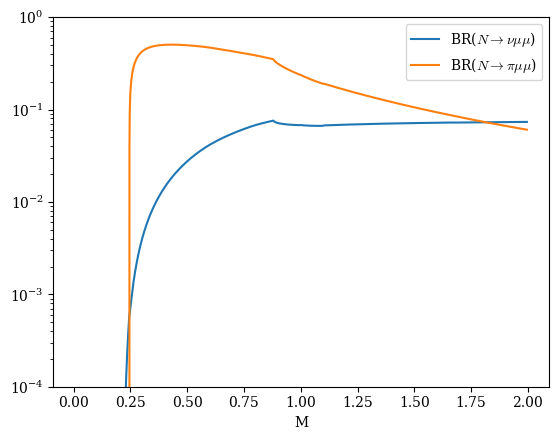

In [7]:
# We load BR precomputated points, and we interpolate the generate functions

file = '/Users/ific/Desktop/protoDUNE_HNL_sensitivity/BR/listBRNvmmM.txt'
BR_N_vmm_M = pd.read_csv(file, sep='\t',names=['logM', 'BR'])
file = '/Users/ific/Desktop/protoDUNE_HNL_sensitivity/BR/listBRNmpiM.txt'
BR_N_mpi_M = pd.read_csv(file, sep='\t',names=['logM', 'BR'])

BR_N_vmm_M['M']=10**BR_N_vmm_M['logM']
BR_N_mpi_M['M']=10**BR_N_mpi_M['logM']

BR_N_vmm_M_fun = interp1d(BR_N_vmm_M['M'], BR_N_vmm_M['BR'], kind='linear', fill_value=None)
BR_N_mpi_M_fun = interp1d(BR_N_mpi_M['M'], BR_N_mpi_M['BR'], kind='linear', fill_value=None)
ax = BR_N_vmm_M.plot('M','BR',logy=True,ylim=(1e-4,1), label=r'BR($N\to \nu\mu\mu$)')
BR_N_mpi_M.plot('M','BR',logy=True,ylim=(1e-4,1), label=r'BR($N\to \pi\mu\mu$)', ax=ax)

In [8]:
BR_N_vmm_M_fun(1.862), BR_N_mpi_M_fun(1.862)

(array(0.0729937), array(0.06923319))

In [ ]:
def theta(px,py,pz):
    Ptot = np.sqrt(px**2 + py**2 + pz**2)
    th = np.arccos(pz / Ptot)
    return th

def thetaS(px1,py1,pz1,px2,py2,pz2): #from Salva's angle variable
    dot_product = px1*px2 + py1*py2 + pz1*pz2
    magnitude1 = px1**2 + py1**2 + pz1**2
    magnitude2 = px2**2 + py2**2 + pz2**2
    th = np.arccos(dot_product/(np.sqrt(magnitude1*magnitude2)))
    return th

def pT(px1,px2,py1,py2):
     ph = np.sqrt((px1+px2)**2+(py1+py2)**2)
     return ph

def pS(px1,px2,py1,py2): #from Salva's momentum variable
     ph1 = np.sqrt((px1)**2+(py1)**2)
     ph2 = np.sqrt((px2)**2+(py2)**2)
     ph = np.sqrt((ph1)**2+(ph2)**2)
     return ph

# Signal

In [10]:
# Load summary files 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/data_NM_kaon+_full.txt'
df_signal_vmm_k_p = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/data_NM_kaon-_full.txt'
df_signal_vmm_k_m = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/data_d+_full.txt'
df_signal_vmm_d_p = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/data_d-_full.txt'
df_signal_vmm_d_m = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/data_ds+_full.txt'
df_signal_vmm_ds_p = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/data_ds-_full.txt'
df_signal_vmm_ds_m = pd.read_csv(file, sep='\t') 

In [11]:
PHF_Kp = 0.542
PHF_Km = 0.211

NHF_Kp = 0.488
NHF_Km = 0.237

# BR_N_vmm_M_fun(df_signal_vmm_ds_m['mass']) I leave it here to check the interpolation function, but I will not use it for the final calculation of Nev, since the mass points in df_signal_vmm_ds_m are not exactly the same as in BR_N_vmm_M, and I don't want to extrapolate.

df_signal_vmm_k_p['Nev'] =(1+NHF_Km/PHF_Kp)*df_signal_vmm_k_p['meson_widthT']/GammaKtonu/2*df_signal_vmm_k_p['total']*PoT/df_signal_vmm_k_p['POT']
df_signal_vmm_k_m['Nev'] =(1+NHF_Kp/PHF_Km)*df_signal_vmm_k_m['meson_widthT']/GammaKtonu/2*df_signal_vmm_k_m['total']*PoT/df_signal_vmm_k_m['POT']

df_signal_vmm_d_m['Nev'] = df_signal_vmm_d_m['meson_widthT']/GammaDtoall*df_signal_vmm_d_m['total']*PoT/df_signal_vmm_d_m['POT']
df_signal_vmm_d_p['Nev'] = df_signal_vmm_d_p['meson_widthT']/GammaDtoall*df_signal_vmm_d_p['total']*PoT/df_signal_vmm_d_p['POT']

df_signal_vmm_ds_m['Nev'] = df_signal_vmm_ds_m['meson_widthT']/GammaDstoall*df_signal_vmm_ds_m['total']*PoT/df_signal_vmm_ds_m['POT']
df_signal_vmm_ds_p['Nev'] = df_signal_vmm_ds_p['meson_widthT']/GammaDstoall*df_signal_vmm_ds_p['total']*PoT/df_signal_vmm_ds_p['POT']

In [12]:
Nev_k_p_vmm_fun = interp1d(df_signal_vmm_k_p['mass'], df_signal_vmm_k_p['Nev'], kind='linear', fill_value=None)
Nev_k_m_vmm_fun = interp1d(df_signal_vmm_k_m['mass'], df_signal_vmm_k_m['Nev'], kind='linear', fill_value=None)

Nev_d_m_vmm_fun = interp1d(df_signal_vmm_d_m['mass'], df_signal_vmm_d_m['Nev'], kind='linear', fill_value=None) 
Nev_d_p_vmm_fun = interp1d(df_signal_vmm_d_p['mass'], df_signal_vmm_d_p['Nev'], kind='linear', fill_value=None) 
Nev_ds_m_vmm_fun = interp1d(df_signal_vmm_ds_m['mass'], df_signal_vmm_ds_m['Nev'], kind='linear', fill_value=None) 
Nev_ds_p_vmm_fun = interp1d(df_signal_vmm_ds_p['mass'], df_signal_vmm_ds_p['Nev'], kind='linear', fill_value=None) 

In [13]:
# Here is where we plug the BR to the specific decay channel 

# N -> nu mu mu
def Nev_vmm_all(m,u2):
    if 10.0**m < df_signal_vmm_k_p['mass'].min():
        nevent = 0
    else:
        if 10.0**m <= df_signal_vmm_k_p['mass'].max():
            nevent = BR_N_vmm_M_fun(10.0**m)*((10.0**u2/1e-6)**2)*(Nev_k_p_vmm_fun(10.0**m) + Nev_k_m_vmm_fun(10.0**m) + Nev_d_m_vmm_fun(10.0**m) + Nev_d_p_vmm_fun(10.0**m) + Nev_ds_m_vmm_fun(10.0**m) + Nev_ds_p_vmm_fun(10.0**m))
        else:
            if 10.0**m <= df_signal_vmm_d_p['mass'].max():
                nevent = BR_N_vmm_M_fun(10.0**m)*((10.0**u2/1e-6)**2)*(Nev_d_m_vmm_fun(10.0**m) + Nev_d_p_vmm_fun(10.0**m) + Nev_ds_m_vmm_fun(10.0**m) + Nev_ds_p_vmm_fun(10.0**m))
            else:
                if 10.0**m <= df_signal_vmm_ds_p['mass'].max():
                    nevent = BR_N_vmm_M_fun(10.0**m)*((10.0**u2/1e-6)**2)*(Nev_ds_m_vmm_fun(10.0**m) + Nev_ds_p_vmm_fun(10.0**m))
                else:
                    nevent = 0
    return nevent

In [14]:
# Load summary files 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/data_NM_kaon+_full.txt'
df_signal_mpi_k_p = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/data_NM_kaon-_full.txt'
df_signal_mpi_k_m = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/data_d+_full.txt'
df_signal_mpi_d_p = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/data_d-_full.txt'
df_signal_mpi_d_m = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/data_ds+_full.txt'
df_signal_mpi_ds_p = pd.read_csv(file, sep='\t') 

file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/data_ds-_full.txt'
df_signal_mpi_ds_m = pd.read_csv(file, sep='\t') 

In [15]:
PHF_Kp = 0.542
PHF_Km = 0.211

NHF_Kp = 0.488
NHF_Km = 0.237

# BR_N_vmm_M_fun(df_signal_mpi_ds_m['mass']) I leave it here to check the interpolation function, but I will not use it for the final calculation of Nev, since the mass points in df_signal_mpi_ds_m are not exactly the same as in BR_N_vmm_M, and I don't want to extrapolate.

df_signal_mpi_k_p['Nev'] =(1+NHF_Km/PHF_Kp)*df_signal_mpi_k_p['meson_widthT']/GammaKtonu/2*df_signal_mpi_k_p['total']*PoT/df_signal_mpi_k_p['POT']
df_signal_mpi_k_m['Nev'] =(1+NHF_Kp/PHF_Km)*df_signal_mpi_k_m['meson_widthT']/GammaKtonu/2*df_signal_mpi_k_m['total']*PoT/df_signal_mpi_k_m['POT']

df_signal_mpi_d_m['Nev'] = df_signal_mpi_d_m['meson_widthT']/GammaDtoall*df_signal_mpi_d_m['total']*PoT/df_signal_mpi_d_m['POT']
df_signal_mpi_d_p['Nev'] = df_signal_mpi_d_p['meson_widthT']/GammaDtoall*df_signal_mpi_d_p['total']*PoT/df_signal_mpi_d_p['POT']

df_signal_mpi_ds_m['Nev'] = df_signal_mpi_ds_m['meson_widthT']/GammaDstoall*df_signal_mpi_ds_m['total']*PoT/df_signal_mpi_ds_m['POT']
df_signal_mpi_ds_p['Nev'] = df_signal_mpi_ds_p['meson_widthT']/GammaDstoall*df_signal_mpi_ds_p['total']*PoT/df_signal_mpi_ds_p['POT']

In [16]:
Nev_k_p_mpi_fun = interp1d(df_signal_mpi_k_p['mass'], df_signal_mpi_k_p['Nev'], kind='linear', fill_value=None)
Nev_k_m_mpi_fun = interp1d(df_signal_mpi_k_m['mass'], df_signal_mpi_k_m['Nev'], kind='linear', fill_value=None)

Nev_d_m_mpi_fun = interp1d(df_signal_mpi_d_m['mass'], df_signal_mpi_d_m['Nev'], kind='linear', fill_value=None) 
Nev_d_p_mpi_fun = interp1d(df_signal_mpi_d_p['mass'], df_signal_mpi_d_p['Nev'], kind='linear', fill_value=None) 
Nev_ds_m_mpi_fun = interp1d(df_signal_mpi_ds_m['mass'], df_signal_mpi_ds_m['Nev'], kind='linear', fill_value=None) 
Nev_ds_p_mpi_fun = interp1d(df_signal_mpi_ds_p['mass'], df_signal_mpi_ds_p['Nev'], kind='linear', fill_value=None) 

In [17]:
# Here is where we plug the BR to the specific decay channel 

# N -> nu mu mu
def Nev_mpi_all(m,u2):
    if 10.0**m < df_signal_mpi_k_p['mass'].min():
        nevent = 0
    else:
        if 10.0**m <= df_signal_mpi_k_p['mass'].max():
            nevent = BR_N_mpi_M_fun(10.0**m)*((10.0**u2/1e-6)**2)*(Nev_k_p_mpi_fun(10.0**m) + Nev_k_m_mpi_fun(10.0**m) + Nev_d_m_mpi_fun(10.0**m) + Nev_d_p_mpi_fun(10.0**m) + Nev_ds_m_mpi_fun(10.0**m) + Nev_ds_p_mpi_fun(10.0**m))
        else:
            if 10.0**m <= df_signal_mpi_d_p['mass'].max():
                nevent = BR_N_mpi_M_fun(10.0**m)*((10.0**u2/1e-6)**2)*(Nev_d_m_mpi_fun(10.0**m) + Nev_d_p_mpi_fun(10.0**m) + Nev_ds_m_mpi_fun(10.0**m) + Nev_ds_p_mpi_fun(10.0**m))
            else:
                if 10.0**m <= df_signal_mpi_ds_p['mass'].max():
                    nevent = BR_N_mpi_M_fun(10.0**m)*((10.0**u2/1e-6)**2)*(Nev_ds_m_mpi_fun(10.0**m) + Nev_ds_p_mpi_fun(10.0**m))
                else:
                    nevent = 0
    return nevent

In [18]:
Nev_vmm_all(np.log10(0.38), -8), Nev_mpi_all(np.log10(0.38), -8)

(513.3026141256914, 21298.21755950298)

In [19]:
# Define the range for m
#m_min = np.log10(df_signal_k_p['mass'].min())
m_min = np.log10(0.2)
m_max = np.log10(2)
m_values = np.linspace(m_min, m_max, 400)  # Adjust number of points as needed

# Define the range for u2
u2_values = np.arange(-1, -11, -0.01)  # From -1 to -10 inclusive

# Create meshgrid
M, U2 = np.meshgrid(m_values, u2_values)

# Compute Nev_all for each point
Nev_vmm_grid = np.vectorize(Nev_vmm_all)(M, U2)

# Create a DataFrame for the grid
grid_vmm_df = pd.DataFrame({
    'm': M.flatten(),
    'u2': U2.flatten(),
    'Nev': Nev_vmm_grid.flatten()
})

grid_vmm_df['m']=10.0**grid_vmm_df['m']
grid_vmm_df['u2']=10.0**grid_vmm_df['u2']

In [20]:
# Define the range for m
#m_min = np.log10(df_signal_k_p['mass'].min())
m_min = -0.7
m_max = np.log10(2)
m_values = np.linspace(m_min, m_max, 400)  # Adjust number of points as needed

# Define the range for u2
u2_values = np.arange(-1, -11, -0.01)  # From -1 to -10 inclusive

# Create meshgrid
M, U2 = np.meshgrid(m_values, u2_values)

# Compute Nev_all for each point
Nev_mpi_grid = np.vectorize(Nev_mpi_all)(M, U2)

# Create a DataFrame for the grid
grid_mpi_df = pd.DataFrame({
    'm': M.flatten(),
    'u2': U2.flatten(),
    'Nev': Nev_mpi_grid.flatten()
})

grid_mpi_df['m']=10.0**grid_mpi_df['m']
grid_mpi_df['u2']=10.0**grid_mpi_df['u2']

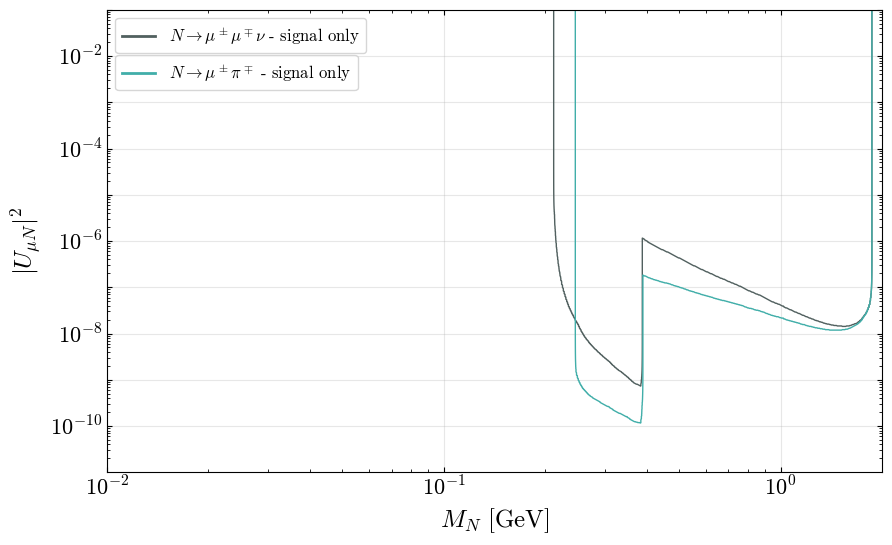

In [21]:
colors = ['#51605F', '#41AEA9']

#m_unique = np.unique(grid_df['m'])
#u2_unique = np.unique(grid_df['u2'])
Nev_vmm_grid = grid_vmm_df.pivot_table(values='Nev', index='u2', columns='m', aggfunc='first')
Nev_mpi_grid = grid_mpi_df.pivot_table(values='Nev', index='u2', columns='m', aggfunc='first')

# Create contour plot
fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contour(Nev_vmm_grid.columns, Nev_vmm_grid.index, Nev_vmm_grid.values, levels=[2.44], colors=colors[0], linewidths=1)
contour = ax.contour(Nev_mpi_grid.columns, Nev_mpi_grid.index, Nev_mpi_grid.values, levels=[2.44], colors=colors[1], linewidths=1)

#ax.clabel(contour, inline=True, fontsize=10)
# 1. Create the first legend (Contour/Line)
line_handle = [Line2D([0], [0], color=colors[0], lw=2)]
line_label = [r'$N\to \mu^\pm\mu^\mp\nu~\text{- signal only}$']
leg1 = ax.legend(line_handle, line_label, loc='upper left', fontsize=12)

# 2. IMPORTANT: Add the first legend manually so it isn't overwritten
ax.add_artist(leg1)

# 3. Create the second legend (Scatter)
# Assuming 'sc' is your scatter plot object: sc = ax.scatter(...)
# If you haven't defined 'sc', you can use a Proxy Artist like this:
line_handle2 = [Line2D([0], [0], color=colors[1], lw=2)]
line_label2 = [r'$N\to \mu^\pm\pi^\mp~\text{- signal only}$']

ax.legend(line_handle2, line_label2, 
          loc='upper left', 
          bbox_to_anchor=(0, 0.92), # Adjust 0.92 based on your plot's aspect ratio
          fontsize=12,
          frameon=True)
# Customize ticks
ax = plt.gca()
# asp_fact=(np.log10(4)-np.log10(1e-3))/(np.log10(ymax)-np.log10(ymin))
# ax.set_aspect(asp_fact)
plt.xscale('log')
plt.yscale('log')

# The logic: hide labels if the log10 of the value is odd
def log_y_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    if exponent % 2 == 0:
        return f'$10^{{{exponent}}}$'
    else:
        return '' # Keep the tick, hide the label
    
def log_x_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    # if exponent % 2 == 0:
    #     return f'$10^{{{exponent}}}$'
    # else:
    #     return '' # Keep the tick, hide the label
    return f'$10^{{{exponent}}}$'

#ax.yaxis.set_major_formatter(plt.FuncFormatter(log_formatter))

# Show ticks on all four sides
ax.tick_params(top=True, right=True, which='both', direction='in')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_x_formatter))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_y_formatter))
ax.tick_params(axis='both', labelsize=16)

plt.xlabel(r'$M_N~[\text{GeV}]$', fontsize=18)
plt.ylabel(r'$|U_{\mu N}|^2$', fontsize=18)
plt.xlim(0.01, 2)
#plt.title(r'Contour at $N_{ev}$ = 2.61')
plt.grid(True, alpha=0.3)
plt.show()

# Signal vs bkg

## bkg events

In [22]:
df_bkg_vmm = pd.DataFrame()

for i in range(0,404):
    if i<9:
        file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_00{i}.txt'
    else:
        if i<99:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_0{i}.txt'
        else:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_{i}.txt'
    if os.path.isfile(file):
        df = pd.read_csv(file, sep='\t')
        df_bkg_vmm = pd.concat([df_bkg_vmm, df], ignore_index=True)
df_bkg_vmm

,event,pdg,px,py,pz,E
0,0,13,-0.495800,-0.336426,61.414156,61.417170
1,0,-13,0.896474,0.399160,0.942188,1.364506
2,0,13,1.736432,0.811889,45.482222,45.522720
3,0,-13,-0.575063,0.436374,1.765281,1.910105
4,0,13,0.244237,-0.697380,3.003336,3.094702
...,...,...,...,...,...,...
137,1,-13,-0.577610,-0.117531,0.549815,0.812962
138,0,13,0.282671,0.458020,4.203148,4.238786
139,0,-13,0.039170,-0.831925,0.765578,1.136181
140,0,13,0.143725,-0.059405,22.560357,22.561141


In [674]:
df_bkg_vmm.items()

<generator object DataFrame.items at 0x29f0633d0>

In [676]:
df_bkg_vmm.iloc[0::2]

,event,pdg,px,py,pz,E
0,0,13,-0.495800,-0.336426,61.414156,61.417170
2,0,13,1.736432,0.811889,45.482222,45.522720
4,0,13,0.244237,-0.697380,3.003336,3.094702
6,0,13,-1.635484,0.031274,21.274774,21.337829
8,0,13,-0.971163,0.031578,16.723424,16.751962
...,...,...,...,...,...,...
132,0,13,-2.361242,1.162518,27.152402,27.279864
134,0,13,0.013435,-0.129848,0.207421,0.266887
136,1,13,0.853311,0.788270,23.484805,23.513757
138,0,13,0.282671,0.458020,4.203148,4.238786


In [ ]:
# 1. Create slices for the rows you need (0, 1, 2 in every block of 4)
df_0 = df_bkg_vmm.iloc[0::2].reset_index(drop=True)
df_1 = df_bkg_vmm.iloc[1::2].reset_index(drop=True)

# 2. Perform vectorized calculations
# This assumes your functions pT, pS, etc., can handle pandas Series
pT_vals = pT(df_0['px'], df_1['px'], df_0['py'], df_1['py'])
pS_vals = pS(df_0['px'], df_1['px'], df_0['py'], df_1['py'])

angle_vals = theta(
    df_0['px'] + df_1['px'], 
    df_0['py'] + df_1['py'], 
    df_0['pz'] + df_1['pz']
)

angleS_vals = thetaS(
    df_0['px'], df_0['py'], df_0['pz'],
    df_1['px'], df_1['py'], df_1['pz']
)

inv1_vals = theta(
    df_0['px'], 
    df_0['py'], 
    df_0['pz']
)*df_0['E'] # Energy1
+ theta(
    df_1['px'], 
    df_1['py'], 
    df_1['pz']
)*df_1['E'] # Energy2           # Cut used by Pablo

inv2_vals = theta(
    df_0['px'] + df_1['px'], 
    df_0['py'] + df_1['py'], 
    df_0['pz'] + df_1['pz']
)*(df_0['E'] + df_1['E']) # Energy1 + Energy2 # Cut used by Joachim 

inv_real = np.sqrt((df_0['E'] + df_1['E'])**2 - 
                       ((df_0['px'] + df_1['px'])**2 + 
                        (df_0['py'] + df_1['py'])**2 +
                        (df_0['pz'] + df_1['pz'])**2)) 

# 3. Create the plot dataframe starting with the first row of each block
df_plot_bkg_vmm_test = df_0.copy()
df_plot_bkg_vmm_test['pT'] = pT_vals
df_plot_bkg_vmm_test['pS'] = pS_vals
df_plot_bkg_vmm_test['Dtheta'] = angle_vals
df_plot_bkg_vmm_test['DthetaS'] = angleS_vals
df_plot_bkg_vmm_test['inv1'] = inv1_vals
df_plot_bkg_vmm_test['inv2'] = inv2_vals
df_plot_bkg_vmm_test['inv_real'] = inv_real

In [701]:
df_plot_bkg_vmm_test['inv_real'].max(), df_plot_bkg_vmm_test['inv1'].max(), df_plot_bkg_vmm_test['inv2'].max()

(9.417008219973745, 3.0025087205715124, 2.8814424025485024)

In [685]:
df_plot_bkg_vmm_test.iloc[60], df_plot_bkg_vmm.iloc[60]

(event       0.000000
 pdg        13.000000
 px         -0.259834
 py          1.032510
 pz          6.591851
 E           6.678117
 pT          0.693738
 pS          1.251343
 Dtheta      0.090537
 DthetaS     0.690289
 inv1        1.069400
 inv2        0.717162
 Name: 60, dtype: float64,
 event       0.000000
 pdg        13.000000
 px         -0.259834
 py          1.032510
 pz          6.591851
 E           6.678117
 pT          0.693738
 pS          1.251343
 Dtheta      0.090537
 DthetaS     0.690289
 Name: 60, dtype: float64)

In [688]:
df_plot_bkg_vmm_test['inv1'].max(), df_plot_bkg_vmm_test['inv2'].max()

(3.0025087205715124, 2.8814424025485024)

In [23]:
df_plot_bkg_vmm = pd.DataFrame()
for i in range(0,len(df_bkg_vmm),2):
    transverse = pT(df_bkg_vmm['px'].loc[i+1],df_bkg_vmm['px'].loc[i],df_bkg_vmm['py'].loc[i+1],df_bkg_vmm['py'].loc[i])
    transverseS = pS(df_bkg_vmm['px'].loc[i+1],df_bkg_vmm['px'].loc[i],df_bkg_vmm['py'].loc[i+1],df_bkg_vmm['py'].loc[i])
    angle = theta(df_bkg_vmm['px'].loc[i+1]+df_bkg_vmm['px'].loc[i],df_bkg_vmm['py'].loc[i+1]+df_bkg_vmm['py'].loc[i],df_bkg_vmm['pz'].loc[i+1]+df_bkg_vmm['pz'].loc[i])
    angleS = thetaS(df_bkg_vmm['px'].loc[i+1],df_bkg_vmm['py'].loc[i+1],df_bkg_vmm['pz'].loc[i+1],df_bkg_vmm['px'].loc[i],df_bkg_vmm['py'].loc[i],df_bkg_vmm['pz'].loc[i])
    #new_colupx = pd.DataFrame([[transverse,transverseS,angle,angleS]],colupxs=['pT','pS','Dtheta','DthetaS'])
    row = df_bkg_vmm.loc[i].copy()
    row['pT'] = transverse
    row['pS'] = transverseS
    row['Dtheta'] = angle
    row['DthetaS'] = angleS
    # frames = [df.loc[i], new_colupx]
    df_plot_bkg_vmm = pd.concat([df_plot_bkg_vmm,row.to_frame().T],ignore_index=True)

In [24]:
df_bkg_pim = pd.DataFrame()

for i in range(0,404):
    if i<9:
        file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_pimu/neutrino_pimu_NDLAr_00{i}.txt'
    else:
        if i<99:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_pimu/neutrino_pimu_NDLAr_0{i}.txt'
        else:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_pimu/neutrino_pimu_NDLAr_{i}.txt'
    if os.path.isfile(file):
        df = pd.read_csv(file, sep='\t')
        df_bkg_pim = pd.concat([df_bkg_pim, df], ignore_index=True)
df_bkg_pim

,event,pdg,px,py,pz,E
0,0,13,0.015429,0.727036,0.914601,1.173234
1,0,211,-0.393083,-0.299341,0.058131,0.516700
2,1,13,-1.262181,-0.847166,10.526615,10.636333
3,1,211,1.287776,0.420409,1.801759,2.258523
4,2,13,-0.869911,1.461266,25.191675,25.249231
...,...,...,...,...,...,...
945705,1155,211,-0.263769,0.549147,0.106288,0.633967
945706,1156,13,0.942654,0.940632,17.697940,17.748286
945707,1156,211,-0.437563,-0.336995,0.078344,0.575017
945708,1157,13,-0.339088,-1.135941,13.467127,13.519616


In [25]:
df_plot_bkg_pim = pd.DataFrame()
for i in range(0,len(df_bkg_pim),2):
    transverse = pT(df_bkg_pim['px'].loc[i+1],df_bkg_pim['px'].loc[i],df_bkg_pim['py'].loc[i+1],df_bkg_pim['py'].loc[i])
    transverseS = pS(df_bkg_pim['px'].loc[i+1],df_bkg_pim['px'].loc[i],df_bkg_pim['py'].loc[i+1],df_bkg_pim['py'].loc[i])
    angle = theta(df_bkg_pim['px'].loc[i+1]+df_bkg_pim['px'].loc[i],df_bkg_pim['py'].loc[i+1]+df_bkg_pim['py'].loc[i],df_bkg_pim['pz'].loc[i+1]+df_bkg_pim['pz'].loc[i])
    angleS = thetaS(df_bkg_pim['px'].loc[i+1],df_bkg_pim['py'].loc[i+1],df_bkg_pim['pz'].loc[i+1],df_bkg_pim['px'].loc[i],df_bkg_pim['py'].loc[i],df_bkg_pim['pz'].loc[i])
    #new_colupx = pd.DataFrame([[transverse,transverseS,angle,angleS]],colupxs=['pT','pS','Dtheta','DthetaS'])
    row = df_bkg_pim.loc[i].copy()
    row['pT'] = transverse
    row['pS'] = transverseS
    row['Dtheta'] = angle
    row['DthetaS'] = angleS
    # frames = [df.loc[i], new_colupx]
    df_plot_bkg_pim = pd.concat([df_plot_bkg_pim,row.to_frame().T],ignore_index=True)

## $\nu$ interactions in ND-LAr (Normalization)

In [26]:
file = uproot.open('/Users/ific/SM_nu_DUNE/Ar40_xsec/xsec_12.root')

graph = file['nu_e_Ar40/tot_cc;1']
df_nue_CC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_e_CC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

graph = file['nu_e_Ar40/tot_nc;1']
df_nue_NC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_e_NC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

file = uproot.open('/Users/ific/SM_nu_DUNE/Ar40_xsec/xsec_14.root')

graph = file['nu_mu_Ar40/tot_cc;1']
df_numu_CC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_mu_CC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

graph = file['nu_mu_Ar40/tot_nc;1']
df_numu_NC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_mu_NC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

file = uproot.open('/Users/ific/SM_nu_DUNE/Ar40_xsec/xsec_16.root')

graph = file['nu_tau_Ar40/tot_cc;1']
df_nutau_CC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_tau_CC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

graph = file['nu_tau_Ar40/tot_nc;1']
df_nutau_NC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_tau_NC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

In [27]:
file = uproot.open('/Users/ific/SM_nu_DUNE/Ar40_xsec/xsec_-12.root')

graph = file['nu_e_bar_Ar40/tot_cc;1']
df_anue_CC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_ae_CC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

graph = file['nu_e_bar_Ar40/tot_nc;1']
df_anue_NC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_ae_NC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

file = uproot.open('/Users/ific/SM_nu_DUNE/Ar40_xsec/xsec_-14.root')

graph = file['nu_mu_bar_Ar40/tot_cc;1']
df_anumu_CC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_amu_CC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

graph = file['nu_mu_bar_Ar40/tot_nc;1']
df_anumu_NC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_amu_NC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

file = uproot.open('/Users/ific/SM_nu_DUNE/Ar40_xsec/xsec_-16.root')

graph = file['nu_tau_bar_Ar40/tot_cc;1']
df_anutau_CC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_atau_CC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

graph = file['nu_tau_bar_Ar40/tot_nc;1']
df_anutau_NC = pd.DataFrame({
    'x': graph.values()[0],
    'y': graph.values()[1]
})
f_xsec_atau_NC = interp1d(graph.values()[0], 1e-38*graph.values()[1])

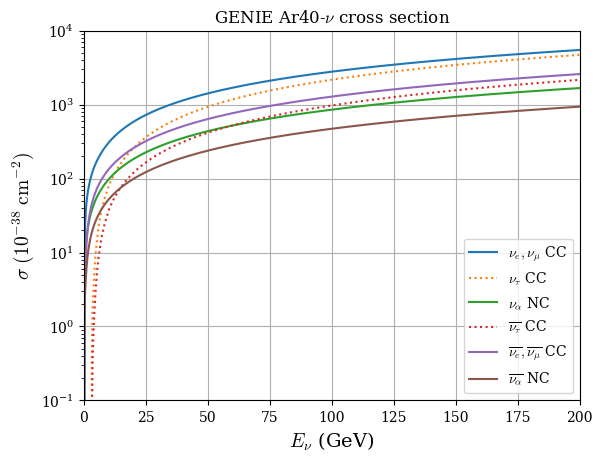

In [28]:
plt.figure()
plt.plot(df_nue_CC['x'], df_nue_CC['y'], label=r'$\nu_e, \nu_\mu$ CC')
plt.plot(df_nutau_CC['x'], df_nutau_CC['y'], label=r'$\nu_\tau$ CC', linestyle=':')

plt.plot(df_nue_NC['x'], df_nue_NC['y'], label=r'$\nu_\alpha$ NC')
plt.plot(df_anutau_CC['x'], df_anutau_CC['y'], label=r'$\overline{\nu_\tau}$ CC', linestyle=':')

plt.plot(df_anue_CC['x'], df_anue_CC['y'], label=r'$\overline{\nu_e}, \overline{\nu_\mu}$ CC')
plt.plot(df_anue_NC['x'], df_anue_NC['y'], label=r'$\overline{\nu_\alpha}$ NC')

plt.yscale('log')
plt.legend(loc='lower right')
plt.xlabel(r'$E_\nu$ (GeV)', fontsize=14)
plt.ylabel(r'$\sigma~ (10^{-38}~\rm{cm}^{-2})$', fontsize=14)
plt.title(r'GENIE Ar40-$\nu$ cross section')
plt.xlim(0,200)
plt.ylim(1e-1,1e4)
plt.grid(True)
plt.show()

In [29]:
def f_xsec_nu(t):
    a = f_xsec_mu_CC(t) + f_xsec_mu_NC(t)
    return a

def f_xsec_nubar(t):
    a = f_xsec_amu_CC(t) + f_xsec_amu_NC(t)
    return a

In [30]:
# # For paper with Salva and Jacobo. We remove 1m of active volume.

# w = 6 # m
# h = 2 # m
# l = 4 # m
# density_LAr = 1.4e6 # g/cm^3

# mass_LAr = w*h*l*density_LAr

In [31]:
w = 7-1 # m, removing 0.5m on each side
h = 3-1 # m, removing 0.5m on each side
l = 5-1 # m, removing 0.5m on each side
density_LAr = 1.4e6 # g/m^3

mass_LAr = w*h*l*density_LAr

In [32]:
mass_LAr/67.2e6

1.0

In [33]:
file = '/Users/ific/Desktop/saltitos_flux_test/histos_g4lbne_v3r5p4_QGSP_BERT_OptimizedEngineeredNov2017_neutrino_LBNEND_globes_flux.txt'
df_LBNEND = pd.read_csv(file, index_col=False, sep=' ', names = ['E', 'nue', 'numu', 'nutau', 'nuebar', 'numubar', 'nutaubar'])

In [34]:
# dic_xsec_function = {
# 'NC': {
#     'nue': df_nue_NCXS_function,
#     'nuebar': df_nuebar_NCXS_function,
#     'numu': df_numu_NCXS_function,
#     'numubar': df_numubar_NCXS_function
# },
# 'CC': {
#     'nue': df_nue_CCXS_function,
#     'nuebar': df_nuebar_CCXS_function,
#     'numu': df_numu_CCXS_function,
#     'numubar': df_numubar_CCXS_function
# }}

dic_xsec_function = {'neutrino': f_xsec_nu, 
                     'antineutrino': f_xsec_nubar, 
                     'neutrinoCC': f_xsec_mu_CC, 
                     'neutrinoNC': f_xsec_mu_NC,
                     'antineutrinoCC': f_xsec_amu_CC, 
                     'antineutrinoNC': f_xsec_amu_NC,}

# def number_events(nu, mode, pot_pd):  

#     bi = 240
#     ran = 240
#     # Create the histogram with weights
#     counts, bin_edges = np.histogram(flujo_all_0mrad['energy'], range=[0,ran], bins=bi, weights=flujo_all_0mrad['%s_flux'%(nu)]/100/100*dic_xsec_function[mode](flujo_all_0mrad['energy'])*(mass_LAr)*(6.022e23)*(1/40)*pot_pd, density=False)
#     # Calculate the midpoints of the bins
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#     # Compute the area under the histogram using weights
#     area = np.trapz(counts, bin_centers)
#     area_2 = np.trapz(counts, bin_edges[1:])
#     return round(area_2)

def number_events_DUNE(nu, mode, pot_pd):  

    bi = 240
    ran = 240
    # Create the histogram with weights
    counts, bin_edges = np.histogram(df_LBNEND['E'], range=[0,ran], bins=bi, weights=df_LBNEND['%s'%(nu)]/100/100*dic_xsec_function[mode](df_LBNEND['E'])*(mass_LAr)*(6.022e23)*(1/40)*pot_pd, density=False)
    # Calculate the midpoints of the bins
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Compute the area under the histogram using weights
    area = np.trapz(counts, bin_centers)
    area_2 = np.trapz(counts, bin_edges[1:])
    return round(area_2)

In [35]:
# def number_events_HNLux_cut(nu, mode, pot_pd):  

#     bi = 240
#     ranO = 0.5
#     ranF=4
#     # Create the histogram with weights
#     counts, bin_edges = np.histogram(flujo_all_0mrad['energy'], range=[ranO,ranF], bins=bi, weights=flujo_all_0mrad['%s_flux'%(nu)]/100/100*dic_xsec_function[mode](flujo_all_0mrad['energy'])*(mass_LAr)*(6.022e23)*(1/40)*pot_pd, density=False)
#     # Calculate the midpoints of the bins
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#     # Compute the area under the histogram using weights
#     area = np.trapz(counts, bin_centers)
#     area_2 = np.trapz(counts, bin_edges[1:])
#     return round(area_2)

In [36]:
def number_events_DUNE_cut(nu, mode, pot_pd):  

    bi = 240
    ranO = 0.5
    ranF=4
    # Create the histogram with weights
    counts, bin_edges = np.histogram(df_LBNEND['E'], range=[ranO,ranF], bins=bi, weights=df_LBNEND['%s'%(nu)]/100/100*dic_xsec_function[mode](df_LBNEND['E'])*(mass_LAr)*(6.022e23)*(1/40)*pot_pd, density=False)
    # Calculate the midpoints of the bins
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Compute the area under the histogram using weights
    area = np.trapz(counts, bin_centers)
    area_2 = np.trapz(counts, bin_edges[1:])
    return round(area_2)

In [37]:
# Total number of CC and NC numu and numubar events in DUNE ND without energy cuts in 7 years of data taking:

tot = number_events_DUNE('numu', 'neutrinoCC', PoT) + number_events_DUNE('numubar', 'antineutrinoCC', PoT) + number_events_DUNE('numu', 'neutrinoNC', PoT) + number_events_DUNE('numubar', 'antineutrinoNC', PoT)
print(f"{tot:.2e}")

4.14e+09


In [38]:
tot_cut = number_events_DUNE_cut('numu', 'neutrinoCC', PoT)+ number_events_DUNE_cut('numubar', 'antineutrinoCC', PoT) + number_events_DUNE_cut('numu', 'neutrinoNC', PoT) + number_events_DUNE_cut('numubar', 'antineutrinoNC', PoT)
print(f"{tot_cut:.2e}")

4.56e+07


In [39]:
# Justo has simulated 2e7 GENIE events. And he told us that 2.192e6 per detector mass (in t) and year

2.192e6*67*7 

1.03e+09

In [40]:
# we need to normalize the events with

norm_bkg = (2.192e6*67*7)/2e7

norm_bkg

51.4024

## Sensitivity

In [41]:
um42_grid = [10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 24, 25, 26, 27, 28, 30, 31, 32, 33, 37, 43, 50, 58, 67, 78, 90, 104, 105, 107, 120, 134, 136, 139, 161, 187, 210, 212, 216, 233, 244, 246, 250, 290, 300, 310, 328, 329, 330, 335, 349, 358, 360, 369, 384, 388, 391, 395, 428, 432, 467, 474, 510, 519, 558, 568, 609, 623, 666, 682, 727, 748, 774, 776, 795, 819, 868, 880, 882, 897, 949, 983, 1018, 1020, 1037, 1058, 1077, 1117, 1132, 1180, 1237, 1293, 1352, 1410, 1416, 1477, 1490, 1499, 1552, 1583, 1587, 1614, 1675, 1676, 1700, 1745, 1763, 1769, 1843, 1862]
masas = um42_grid
# Create a dictionary to hold your dataframes
dfs_k_signal_vmm = {}

for masa in masas:
    file_test = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-n~decay-{masa}MeV-1e-06-fromNM_kaon-.dat'
    if os.path.exists(file_test):
        # --- Process Kaon+ ---
        file_kp = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-ndecay-{masa}MeV-1e-06-fromNM_kaon+.dat'
        df_signal_kp = pd.read_csv(file_kp, sep='\t')
        
        df_signal_kp['weight'] = (1 + NHF_Km/PHF_Kp) * df_signal_kp['M_weight'] * \
                                df_signal_kp['N_weight_final'] * BR_N_vmm_M_fun(masa/1e3) * \
                                df_signal_kp['M_width_CM'] / GammaKtonu/2 / \
                                df_signal_kp['PoT_f'] * PoT

        # --- Process Kaon- ---
        file_km = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-n~decay-{masa}MeV-1e-06-fromNM_kaon-.dat'
        df_signal_km = pd.read_csv(file_km, sep='\t')
        
        df_signal_km['weight'] = (1 + NHF_Kp/PHF_Km) * df_signal_km['M_weight'] * \
                                df_signal_km['N_weight_final'] * BR_N_vmm_M_fun(masa/1e3) * \
                                df_signal_km['M_width_CM'] / GammaKtonu/2 / \
                                df_signal_km['PoT_f'] * PoT

        # Combine and store in the dictionary using the mass as the key
        dfs_k_signal_vmm[f'{masa}'] = pd.concat([df_signal_kp, df_signal_km], ignore_index=True)

        # df_signal_km['BR_N'] * \

In [648]:
dfs_k_signal_vmm['212'].head()

,M_weight,N_weight,MN,USQUARED,L_lab_N,x_0,y_0,z_0,thetaN,phiN,...,time_nu,PoT_f,N_weight_final,E,dist_to_enter,dist_in_det,x_final,y_final,z_final,weight
0,171.429,2.173850e-06,0.212000,0.000001,1.113180e+07,-0.270671,-1.156710,27.8807,0.005824,1.02669,...,0.000002,100000000.0,4.513118e-07,1.097479,548.520683,5.024161,2.470792,0.501944,578.038486,0.000066
1,-13.000,5.407735e-01,-0.002469,0.002519,5.303390e-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13.000,5.557893e-01,0.007980,0.000435,5.455950e-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,14000.000,9.161265e-04,-0.000145,0.000292,8.559996e-04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,128.571,5.821060e-07,0.212000,0.000001,4.174450e+07,-0.940177,0.573112,115.3400,0.003562,-2.63571,...,0.000002,100000000.0,1.204272e-07,4.043627,461.192937,5.027231,-1.738029,-0.867143,577.532929,0.000013


In [657]:
np.sqrt(dfs_k_signal_mpi['388'].iloc[1]['N_weight']**2-(dfs_k_signal_mpi['388'].iloc[1]['MN']**2+dfs_k_signal_mpi['388'].iloc[1]['USQUARED']**2+dfs_k_signal_mpi['388'].iloc[1]['L_lab_N']**2))

0.13957000000101005

In [658]:
np.sqrt(dfs_k_signal_mpi['388'].iloc[2]['N_weight']**2-(dfs_k_signal_mpi['388'].iloc[2]['MN']**2+dfs_k_signal_mpi['388'].iloc[2]['USQUARED']**2+dfs_k_signal_mpi['388'].iloc[2]['L_lab_N']**2))

0.10566000000013297

In [654]:
np.sqrt(dfs_k_signal_vmm['212'].iloc[3]['N_weight']**2-(dfs_k_signal_vmm['212'].iloc[3]['MN']**2+dfs_k_signal_vmm['212'].iloc[3]['USQUARED']**2+dfs_k_signal_vmm['212'].iloc[3]['L_lab_N']**2))

1.6347731282972263e-08

In [42]:
dfs_d_signal_vmm = {}

for masa in masas:
    file_test = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-n~decay-{masa}MeV-1e-06-fromd-.dat'
    if os.path.exists(file_test):
        # --- Process Kaon+ ---
        file_dp = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-ndecay-{masa}MeV-1e-06-fromd+.dat'
        df_signal_dp = pd.read_csv(file_dp, sep='\t')
        
        df_signal_dp['weight'] = df_signal_dp['M_weight'] * \
                                df_signal_dp['N_weight_final'] * BR_N_vmm_M_fun(masa/1e3) * \
                                df_signal_dp['M_width_CM'] / GammaDtoall / \
                                df_signal_dp['PoT_f'] * PoT

        # --- Process Kaon- ---
        file_dm = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-n~decay-{masa}MeV-1e-06-fromd-.dat'
        df_signal_dm = pd.read_csv(file_dm, sep='\t')
        
        df_signal_dm['weight'] = df_signal_dm['M_weight'] * \
                                df_signal_dm['N_weight_final'] * BR_N_vmm_M_fun(masa/1e3) * \
                                df_signal_dm['M_width_CM'] / GammaDtoall / \
                                df_signal_dm['PoT_f'] * PoT

        # Combine and store in the dictionary using the mass as the key
        dfs_d_signal_vmm[f'{masa}'] = pd.concat([df_signal_dp, df_signal_dm], ignore_index=True)

In [43]:
dfs_ds_signal_vmm = {}

for masa in masas:
    file_test = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-n~decay-{masa}MeV-1e-06-fromds-.dat'
    if os.path.exists(file_test):
        # --- Process Kaon+ ---
        file_dsp = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-ndecay-{masa}MeV-1e-06-fromds+.dat'
        df_signal_dsp = pd.read_csv(file_dsp, sep='\t')
        
        df_signal_dsp['weight'] = df_signal_dsp['M_weight'] * \
                                df_signal_dsp['N_weight_final'] * BR_N_vmm_M_fun(masa/1e3) * \
                                df_signal_dsp['M_width_CM'] / GammaDtoall / \
                                df_signal_dsp['PoT_f'] * PoT

        # --- Process Kaon- ---
        file_dsm = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_numumu/filter/events-n~decay-{masa}MeV-1e-06-fromds-.dat'
        df_signal_dsm = pd.read_csv(file_dsm, sep='\t')
        
        df_signal_dsm['weight'] = df_signal_dsm['M_weight'] * \
                                df_signal_dsm['N_weight_final'] * BR_N_vmm_M_fun(masa/1e3) * \
                                df_signal_dsm['M_width_CM'] / GammaDtoall / \
                                df_signal_dsm['PoT_f'] * PoT

        # Combine and store in the dictionary using the mass as the key
        dfs_ds_signal_vmm[f'{masa}'] = pd.concat([df_signal_dsp, df_signal_dsm], ignore_index=True)

In [44]:
dfs_k_signal_vmm.keys()

dict_keys(['212', '216', '233', '244', '246', '250', '290', '310', '330', '335', '349', '369', '384', '388'])

In [659]:
dfs_k_signal_vmm['212'].head()

,M_weight,N_weight,MN,USQUARED,L_lab_N,x_0,y_0,z_0,thetaN,phiN,...,time_nu,PoT_f,N_weight_final,E,dist_to_enter,dist_in_det,x_final,y_final,z_final,weight
0,171.429,2.173850e-06,0.212000,0.000001,1.113180e+07,-0.270671,-1.156710,27.8807,0.005824,1.02669,...,0.000002,100000000.0,4.513118e-07,1.097479,548.520683,5.024161,2.470792,0.501944,578.038486,0.000066
1,-13.000,5.407735e-01,-0.002469,0.002519,5.303390e-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13.000,5.557893e-01,0.007980,0.000435,5.455950e-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,14000.000,9.161265e-04,-0.000145,0.000292,8.559996e-04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,128.571,5.821060e-07,0.212000,0.000001,4.174450e+07,-0.940177,0.573112,115.3400,0.003562,-2.63571,...,0.000002,100000000.0,1.204272e-07,4.043627,461.192937,5.027231,-1.738029,-0.867143,577.532929,0.000013


In [711]:
1+np.random.normal(0, sfv, size=len(df_k_signal_vmm_plot['212']))

array([1.06075038, 1.14900639, 0.95609883, ..., 1.02402868, 0.93420474,
       1.11413089])

In [715]:
sfv = 20/100 # We apply a 20% smearing factor to the momentum of the HNL, as a conservative estimate of the detector resolution. This will affect the decay length and thus the number of events passing the cuts.

def apply_smearing(df, sf=sfv):
    # Apply smearing to the momentum of the HNL
    
    # Recalculate the decay length and other dependent variables if needed
    # For example, if you have a decay length column, you would recalculate it here based on the smeared momentum.
    
    return df * (1 + np.random.normal(0, sf, size=len(df)))

In [718]:
df_0['px']

0    -0.495800
1     1.736432
2     0.244237
3    -1.635484
4    -0.971163
        ...   
66   -2.361242
67    0.013435
68    0.853311
69    0.282671
70    0.143725
Name: px, Length: 71, dtype: float64

In [719]:
apply_smearing(df_0['px'])

0    -0.525278
1     0.906314
2     0.233888
3    -1.624968
4    -1.173960
        ...   
66   -2.256397
67    0.015308
68    0.614438
69    0.241896
70    0.123162
Name: px, Length: 71, dtype: float64

In [724]:
df_3

,M_weight,N_weight,MN,USQUARED,L_lab_N,x_0,y_0,z_0,thetaN,phiN,...,dist_to_enter,dist_in_det,x_final,y_final,z_final,weight,px_s,py_s,pz_s,E_s
0,14000.0,0.297435,-0.072395,-0.097502,0.271514,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.082731,-0.088301,0.300690,0.228939
1,14000.0,0.378683,0.018875,0.075784,0.370542,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.015920,0.059160,0.351143,0.441018
2,14000.0,0.065942,0.050177,-0.024737,0.034908,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.045038,-0.027851,0.029578,0.045547
3,14000.0,0.298256,0.019046,0.081340,0.286317,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.019203,0.065484,0.284514,0.361071
4,14000.0,0.231653,0.050409,-0.015317,0.225583,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.043999,-0.019256,0.271359,0.205797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135214,-14000.0,0.352712,0.027597,0.001710,0.351627,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.018650,0.002332,0.509403,0.437155
135215,-14000.0,0.013355,-0.001516,0.006347,0.011652,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.001950,0.006479,0.012933,0.015677
135216,-14000.0,4.948229,0.127441,-0.002021,4.946587,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.168057,-0.002415,4.562151,3.541761
135217,-14000.0,5.956858,0.117970,0.032607,5.955600,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.085983,0.035423,7.062130,7.750422


In [732]:
# Create a new dictionary to hold the results for plotting
df_k_signal_vmm_plot = {}

for name, df in dfs_k_signal_vmm.items():
    muon_mass = 0.105658 # GeV

    # 1. Create slices for the rows you need (0, 1, 2 in every block of 4)
    df_0 = df.iloc[0::4].reset_index(drop=True)
    df_1 = df.iloc[1::4].reset_index(drop=True)
    df_2 = df.iloc[2::4].reset_index(drop=True)
    df_3 = df.iloc[3::4].reset_index(drop=True)

    # 2. Perform vectorized calculations
    # This assumes your functions pT, pS, etc., can handle pandas Series
    pT_vals = pT(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    pS_vals = pS(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    
    angle_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )
    
    angleS_vals = thetaS(
        df_1['MN'], df_1['USQUARED'], df_1['L_lab_N'],
        df_2['MN'], df_2['USQUARED'], df_2['L_lab_N']
    )
    
    inv1_vals = theta(
        df_1['MN'], 
        df_1['USQUARED'], 
        df_1['L_lab_N']
    )*df_1['N_weight'] # Energy1
    + theta(
        df_2['MN'], 
        df_2['USQUARED'], 
        df_2['L_lab_N']
    )*df_2['N_weight'] # Energy2

    inv2_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )*(df_1['N_weight'] + df_2['N_weight']) # Energy1 + Energy2

    df_1['px_s'] = apply_smearing(df_1['MN'])
    df_1['py_s'] = apply_smearing(df_1['USQUARED'])
    df_1['pz_s'] = apply_smearing(df_1['L_lab_N'])
    mass = muon_mass # GeV
    df_1['E_s'] = np.sqrt(df_1['px_s']**2 + df_1['py_s']**2 + df_1['pz_s']**2 + mass**2)
    #apply_smearing(df_1['N_weight'])  

    df_2['px_s'] = apply_smearing(df_2['MN'])
    df_2['py_s'] = apply_smearing(df_2['USQUARED'])
    df_2['pz_s'] = apply_smearing(df_2['L_lab_N'])
    mass = muon_mass # GeV
    df_2['E_s'] = np.sqrt(df_2['px_s']**2 + df_2['py_s']**2 + df_2['pz_s']**2 + mass**2)
    #apply_smearing(df_2['N_weight'])  

    # df_3['px_s'] = apply_smearing(df_3['MN'])
    # df_3['py_s'] = apply_smearing(df_3['USQUARED'])
    # df_3['pz_s'] = apply_smearing(df_3['L_lab_N'])
    # df_3['E_s'] = apply_smearing(df_3['N_weight'])

    inv_real = np.sqrt((df_1['E_s'] + df_2['E_s'])**2 - 
                       ((df_1['px_s'] + df_2['px_s'])**2 + 
                        (df_1['py_s'] + df_2['py_s'])**2 +
                        (df_1['pz_s'] + df_2['pz_s'])**2))

    # 3. Create the plot dataframe starting with the first row of each block
    df_plot = df_0.copy()
    df_plot['pT'] = pT_vals
    df_plot['pS'] = pS_vals
    df_plot['Dtheta'] = angle_vals
    df_plot['DthetaS'] = angleS_vals
    df_plot['inv1'] = inv1_vals
    df_plot['inv2'] = inv2_vals
    df_plot['inv_real'] = inv_real

    # Store it back in the results dictionary
    df_k_signal_vmm_plot[f'{name}'] = df_plot

In [733]:
df_k_signal_vmm_plot['212'].inv_real.max(), df_k_signal_vmm_plot['212'].inv_real.min()

(0.323874715333393, 0.21131621613641818)

In [728]:
df_k_signal_vmm_plot['212'].inv_real.max(), df_k_signal_vmm_plot['212'].inv_real.min()

(0.32373809936800463, 0.21131671960978787)

In [730]:
212*(1-0.2), 212*(1+0.2)

(169.60000000000002, 254.39999999999998)

In [746]:
n_eps = 1e-6
df_k_signal_vmm_plot['388'][df_k_signal_vmm_plot['388']['inv1']<=388/1000+n_eps].weight.sum(), df_k_signal_vmm_plot['388'][df_k_signal_vmm_plot['388']['inv2']<=388/1000+n_eps].weight.sum(), df_k_signal_vmm_plot['388'][(df_k_signal_vmm_plot['388']['inv_real']<=388/1000*(1+0.3)) & (df_k_signal_vmm_plot['388']['inv_real']>=388/1000*(1-0.3))].weight.sum()

(629142.2731735472, 629142.0623589179, 339225.28551751375)

In [697]:
df_k_signal_vmm_plot['388']['inv_real'].max(), df_k_signal_vmm_plot['388']['inv_real'].min()

(0.3880000002813923, 0.3879999996719371)

In [ ]:
# Create a new dictionary to hold the results for plotting
df_d_signal_vmm_plot = {}

for name, df in dfs_d_signal_vmm.items():
    # 1. Create slices for the rows you need (0, 1, 2 in every block of 4)
    df_0 = df.iloc[0::4].reset_index(drop=True)
    df_1 = df.iloc[1::4].reset_index(drop=True)
    df_2 = df.iloc[2::4].reset_index(drop=True)
    df_3 = df.iloc[3::4].reset_index(drop=True)  # We need nu info for inv_real

    # 2. Perform vectorized calculations
    # This assumes your functions pT, pS, etc., can handle pandas Series
    pT_vals = pT(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    pS_vals = pS(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    
    angle_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )
    
    angleS_vals = thetaS(
        df_1['MN'], df_1['USQUARED'], df_1['L_lab_N'],
        df_2['MN'], df_2['USQUARED'], df_2['L_lab_N']
    )

    inv1_vals = theta(
        df_1['MN'], 
        df_1['USQUARED'], 
        df_1['L_lab_N']
    )*df_1['N_weight'] # Energy1
    + theta(
        df_2['MN'], 
        df_2['USQUARED'], 
        df_2['L_lab_N']
    )*df_2['N_weight'] # Energy2

    inv2_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )*(df_1['N_weight'] + df_2['N_weight']) # Energy1 + Energy2

    inv_real = np.sqrt((df_1['N_weight'] + df_2['N_weight'] + df_3['N_weight'])**2 - 
                       ((df_1['MN'] + df_2['MN'] + df_3['MN'])**2 + 
                        (df_1['USQUARED'] + df_2['USQUARED'] + df_3['USQUARED'])**2
                        +(df_1['L_lab_N'] + df_2['L_lab_N'] + df_3['L_lab_N'])**2))

    # 3. Create the plot dataframe starting with the first row of each block
    df_plot = df_0.copy()
    df_plot['pT'] = pT_vals
    df_plot['pS'] = pS_vals
    df_plot['Dtheta'] = angle_vals
    df_plot['DthetaS'] = angleS_vals
    df_plot['inv1'] = inv1_vals
    df_plot['inv2'] = inv2_vals
    df_plot['inv_real'] = inv_real

    # Store it back in the results dictionary
    df_d_signal_vmm_plot[f'{name}'] = df_plot

In [692]:
# Create a new dictionary to hold the results for plotting
df_ds_signal_vmm_plot = {}

for name, df in dfs_ds_signal_vmm.items():
    # 1. Create slices for the rows you need (0, 1, 2 in every block of 4)
    df_0 = df.iloc[0::4].reset_index(drop=True)
    df_1 = df.iloc[1::4].reset_index(drop=True)
    df_2 = df.iloc[2::4].reset_index(drop=True)
    df_3 = df.iloc[3::4].reset_index(drop=True)

    # 2. Perform vectorized calculations
    # This assumes your functions pT, pS, etc., can handle pandas Series
    pT_vals = pT(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    pS_vals = pS(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    
    angle_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )
    
    angleS_vals = thetaS(
        df_1['MN'], df_1['USQUARED'], df_1['L_lab_N'],
        df_2['MN'], df_2['USQUARED'], df_2['L_lab_N']
    )

    inv1_vals = theta(
        df_1['MN'], 
        df_1['USQUARED'], 
        df_1['L_lab_N']
    )*df_1['N_weight'] # Energy1
    + theta(
        df_2['MN'], 
        df_2['USQUARED'], 
        df_2['L_lab_N']
    )*df_2['N_weight'] # Energy2

    inv2_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )*(df_1['N_weight'] + df_2['N_weight']) # Energy1 + Energy2

    inv_real = np.sqrt((df_1['N_weight'] + df_2['N_weight'] + df_3['N_weight'])**2 - 
                       ((df_1['MN'] + df_2['MN'] + df_3['MN'])**2 + 
                        (df_1['USQUARED'] + df_2['USQUARED'] + df_3['USQUARED'])**2
                        +(df_1['L_lab_N'] + df_2['L_lab_N'] + df_3['L_lab_N'])**2))

    # 3. Create the plot dataframe starting with the first row of each block
    df_plot = df_0.copy()
    df_plot['pT'] = pT_vals
    df_plot['pS'] = pS_vals
    df_plot['Dtheta'] = angle_vals
    df_plot['DthetaS'] = angleS_vals
    df_plot['inv1'] = inv1_vals
    df_plot['inv2'] = inv2_vals
    df_plot['inv_real'] = inv_real

    # Store it back in the results dictionary
    df_ds_signal_vmm_plot[f'{name}'] = df_plot

In [694]:
df_ds_signal_vmm_plot['212']['inv_real'].min()

0.2119999994889143

In [50]:
um42_grid = [10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 24, 25, 26, 27, 28, 30, 31, 32, 33, 37, 43, 50, 58, 67, 78, 90, 104, 105, 107, 120, 134, 136, 139, 161, 187, 210, 212, 216, 233, 244, 246, 250, 290, 300, 310, 328, 329, 330, 335, 349, 358, 360, 369, 384, 388, 391, 395, 428, 432, 467, 474, 510, 519, 558, 568, 609, 623, 666, 682, 727, 748, 774, 776, 795, 819, 868, 880, 882, 897, 949, 983, 1018, 1020, 1037, 1058, 1077, 1117, 1132, 1180, 1237, 1293, 1352, 1410, 1416, 1477, 1490, 1499, 1552, 1583, 1587, 1614, 1675, 1676, 1700, 1745, 1763, 1769, 1843, 1862]
masas = um42_grid
# Create a dictionary to hold your dataframes
dfs_k_signal_mpi = {}

for masa in masas:
    file_test = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-n~decay-{masa}MeV-1e-06-fromNM_kaon-.dat'
    if os.path.exists(file_test):
        # --- Process Kaon+ ---
        file_kp = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-ndecay-{masa}MeV-1e-06-fromNM_kaon+.dat'
        df_signal_kp = pd.read_csv(file_kp, sep='\t')
        
        df_signal_kp['weight'] = (1 + NHF_Km/PHF_Kp) * df_signal_kp['M_weight'] * \
                                df_signal_kp['N_weight_final'] * BR_N_mpi_M_fun(masa/1e3) * \
                                df_signal_kp['M_width_CM'] / GammaKtonu/2 / \
                                df_signal_kp['PoT_f'] * PoT

        # --- Process Kaon- ---
        file_km = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-n~decay-{masa}MeV-1e-06-fromNM_kaon-.dat'
        df_signal_km = pd.read_csv(file_km, sep='\t')
        
        df_signal_km['weight'] = (1 + NHF_Kp/PHF_Km) * df_signal_km['M_weight'] * \
                                df_signal_km['N_weight_final'] * BR_N_mpi_M_fun(masa/1e3) * \
                                df_signal_km['M_width_CM'] / GammaKtonu/2 / \
                                df_signal_km['PoT_f'] * PoT

        # Combine and store in the dictionary using the mass as the key
        dfs_k_signal_mpi[f'{masa}'] = pd.concat([df_signal_kp, df_signal_km], ignore_index=True)

        # df_signal_km['BR_N'] * \
dfs_d_signal_mpi = {}

for masa in masas:
    file_test = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-n~decay-{masa}MeV-1e-06-fromd-.dat'
    if os.path.exists(file_test):
        # --- Process Kaon+ ---
        file_dp = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-ndecay-{masa}MeV-1e-06-fromd+.dat'
        df_signal_dp = pd.read_csv(file_dp, sep='\t')
        
        df_signal_dp['weight'] = df_signal_dp['M_weight'] * \
                                df_signal_dp['N_weight_final'] * BR_N_mpi_M_fun(masa/1e3) * \
                                df_signal_dp['M_width_CM'] / GammaDtoall / \
                                df_signal_dp['PoT_f'] * PoT

        # --- Process Kaon- ---
        file_dm = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-n~decay-{masa}MeV-1e-06-fromd-.dat'
        df_signal_dm = pd.read_csv(file_dm, sep='\t')
        
        df_signal_dm['weight'] = df_signal_dm['M_weight'] * \
                                df_signal_dm['N_weight_final'] * BR_N_mpi_M_fun(masa/1e3) * \
                                df_signal_dm['M_width_CM'] / GammaDtoall / \
                                df_signal_dm['PoT_f'] * PoT

        # Combine and store in the dictionary using the mass as the key
        dfs_d_signal_mpi[f'{masa}'] = pd.concat([df_signal_dp, df_signal_dm], ignore_index=True)
dfs_ds_signal_mpi = {}

for masa in masas:
    file_test = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-n~decay-{masa}MeV-1e-06-fromds-.dat'
    if os.path.exists(file_test):
        # --- Process Kaon+ ---
        file_dsp = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-ndecay-{masa}MeV-1e-06-fromds+.dat'
        df_signal_dsp = pd.read_csv(file_dsp, sep='\t')
        
        df_signal_dsp['weight'] = df_signal_dsp['M_weight'] * \
                                df_signal_dsp['N_weight_final'] * BR_N_mpi_M_fun(masa/1e3) * \
                                df_signal_dsp['M_width_CM'] / GammaDtoall / \
                                df_signal_dsp['PoT_f'] * PoT

        # --- Process Kaon- ---
        file_dsm = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/Um42/to_mupi/filter/events-n~decay-{masa}MeV-1e-06-fromds-.dat'
        df_signal_dsm = pd.read_csv(file_dsm, sep='\t')
        
        df_signal_dsm['weight'] = df_signal_dsm['M_weight'] * \
                                df_signal_dsm['N_weight_final'] * BR_N_mpi_M_fun(masa/1e3) * \
                                df_signal_dsm['M_width_CM'] / GammaDtoall / \
                                df_signal_dsm['PoT_f'] * PoT

        # Combine and store in the dictionary using the mass as the key
        dfs_ds_signal_mpi[f'{masa}'] = pd.concat([df_signal_dsp, df_signal_dsm], ignore_index=True)
dfs_k_signal_mpi.keys()
# Create a new dictionary to hold the results for plotting
df_k_signal_mpi_plot = {}

for name, df in dfs_k_signal_mpi.items():
    # 1. Create slices for the rows you need (0, 1, 2 in every block of 3)
    df_0 = df.iloc[0::3].reset_index(drop=True)
    df_1 = df.iloc[1::3].reset_index(drop=True)
    df_2 = df.iloc[2::3].reset_index(drop=True)

    # 2. Perform vectorized calculations
    # This assumes your functions pT, pS, etc., can handle pandas Series
    pT_vals = pT(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    pS_vals = pS(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    
    angle_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )
    
    angleS_vals = thetaS(
        df_1['MN'], df_1['USQUARED'], df_1['L_lab_N'],
        df_2['MN'], df_2['USQUARED'], df_2['L_lab_N']
    )

    # 3. Create the plot dataframe starting with the first row of each block
    df_plot = df_0.copy()
    df_plot['pT'] = pT_vals
    df_plot['pS'] = pS_vals
    df_plot['Dtheta'] = angle_vals
    df_plot['DthetaS'] = angleS_vals

    # Store it back in the results dictionary
    df_k_signal_mpi_plot[f'{name}'] = df_plot
# Create a new dictionary to hold the results for plotting
df_d_signal_mpi_plot = {}

for name, df in dfs_d_signal_mpi.items():
    # 1. Create slices for the rows you need (0, 1, 2 in every block of 3)
    df_0 = df.iloc[0::3].reset_index(drop=True)
    df_1 = df.iloc[1::3].reset_index(drop=True)
    df_2 = df.iloc[2::3].reset_index(drop=True)

    # 2. Perform vectorized calculations
    # This assumes your functions pT, pS, etc., can handle pandas Series
    pT_vals = pT(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    pS_vals = pS(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    
    angle_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )
    
    angleS_vals = thetaS(
        df_1['MN'], df_1['USQUARED'], df_1['L_lab_N'],
        df_2['MN'], df_2['USQUARED'], df_2['L_lab_N']
    )

    # 3. Create the plot dataframe starting with the first row of each block
    df_plot = df_0.copy()
    df_plot['pT'] = pT_vals
    df_plot['pS'] = pS_vals
    df_plot['Dtheta'] = angle_vals
    df_plot['DthetaS'] = angleS_vals

    # Store it back in the results dictionary
    df_d_signal_mpi_plot[f'{name}'] = df_plot
# Create a new dictionary to hold the results for plotting
df_ds_signal_mpi_plot = {}

for name, df in dfs_ds_signal_mpi.items():
    # 1. Create slices for the rows you need (0, 1, 2 in every block of 3)
    df_0 = df.iloc[0::3].reset_index(drop=True)
    df_1 = df.iloc[1::3].reset_index(drop=True)
    df_2 = df.iloc[2::3].reset_index(drop=True)

    # 2. Perform vectorized calculations
    # This assumes your functions pT, pS, etc., can handle pandas Series
    pT_vals = pT(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    pS_vals = pS(df_1['MN'], df_2['MN'], df_1['USQUARED'], df_2['USQUARED'])
    
    angle_vals = theta(
        df_1['MN'] + df_2['MN'], 
        df_1['USQUARED'] + df_2['USQUARED'], 
        df_1['L_lab_N'] + df_2['L_lab_N']
    )
    
    angleS_vals = thetaS(
        df_1['MN'], df_1['USQUARED'], df_1['L_lab_N'],
        df_2['MN'], df_2['USQUARED'], df_2['L_lab_N']
    )

    # 3. Create the plot dataframe starting with the first row of each block
    df_plot = df_0.copy()
    df_plot['pT'] = pT_vals
    df_plot['pS'] = pS_vals
    df_plot['Dtheta'] = angle_vals
    df_plot['DthetaS'] = angleS_vals

    # Store it back in the results dictionary
    df_ds_signal_mpi_plot[f'{name}'] = df_plot
df_k_signal_mpi_plot.keys()

dict_keys(['246', '250', '290', '310', '330', '335', '349', '369', '384', '388'])

In [51]:
df_k_signal_mpi_plot['246']

,M_weight,N_weight,MN,USQUARED,L_lab_N,x_0,y_0,z_0,thetaN,phiN,...,dist_to_enter,dist_in_det,x_final,y_final,z_final,weight,pT,pS,Dtheta,DthetaS
0,257.1430,7.041650e-06,0.246,0.000001,3436280.0,-1.163590,1.371080,172.11100,0.003502,-1.678510,...,404.210397,5.025834,-2.588160,1.217038,581.262433,4693.071162,0.003155,0.013787,0.003502,0.043555
1,225.0000,4.487550e-06,0.246,0.000001,5392120.0,-0.036723,0.027266,1.22936,0.004726,-1.570020,...,575.216534,5.025666,-2.765270,0.029385,578.560952,2616.882805,0.006681,0.012752,0.004726,0.024582
2,200.0000,1.486860e-06,0.246,0.000001,16275500.0,0.676929,-0.166495,124.09300,0.008746,-1.679290,...,452.427049,5.026286,-3.261901,-0.595518,577.086374,770.805779,0.037320,0.027688,0.008746,0.005636
3,100.0000,2.741460e-06,0.246,0.000001,8863320.0,-0.033560,0.014501,1.86753,0.000498,1.509940,...,574.571754,5.025597,0.253182,0.031972,578.186901,707.582626,0.001158,0.006801,0.000498,0.008227
4,75.6303,2.157560e-06,0.246,0.000001,11262200.0,0.666078,0.338145,20.76610,0.003588,-1.324620,...,555.596418,5.025198,-1.274396,0.825734,578.369422,421.132272,0.010595,0.014500,0.003588,0.011899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33150,4.0000,5.590340e-07,0.246,0.000001,43467500.0,-0.137917,0.172843,49.48850,0.006384,1.852660,...,527.042008,5.026618,3.103682,-0.765837,578.138340,13.305670,0.072749,0.052350,0.006384,0.001869
33151,4.0000,3.008350e-07,0.246,0.000001,80774900.0,-0.035237,0.327714,99.81100,0.004737,2.596790,...,476.799356,1.345940,1.135809,-1.604779,576.794123,1.917245,0.100322,0.071142,0.004737,0.001734
33152,4.0000,2.757250e-07,0.246,0.000001,88131300.0,-1.225690,-0.847893,189.00400,0.005189,-1.326610,...,387.480330,5.025040,-3.191445,-0.358109,579.421002,6.560519,0.119894,0.087214,0.005189,0.001509
33153,4.0000,4.556070e-07,0.246,0.000001,53115800.0,0.309199,-0.648648,182.76600,0.003501,0.682478,...,393.636209,5.024259,1.180192,0.422990,577.188939,10.883681,0.048756,0.034570,0.003501,0.000239


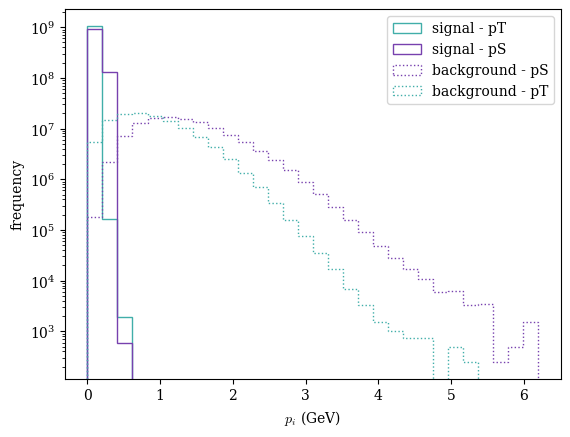

In [52]:
rango = 6.2
bines = 30

plt.hist(df_k_signal_mpi_plot['384']['pT'],label= 'signal - pT', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
plt.hist(df_k_signal_mpi_plot['384']['pS'],label= 'signal - pS', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
plt.hist(df_plot_bkg_pim['pS'],label= 'background - pS', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg_pim['pS']/df_plot_bkg_pim['pS'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step', linestyle=':')
plt.hist(df_plot_bkg_pim['pT'],label= 'background - pT', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg_pim['pT']/df_plot_bkg_pim['pT'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')
plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$p_i$ (GeV)')
#plt.xlim((0,4))
plt.ylabel(r'frequency')
plt.yscale('log')
#plt.ylim((0,0.01))
plt.show()

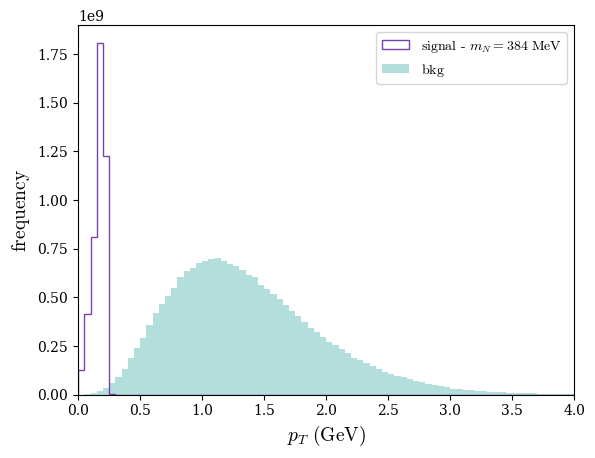

In [631]:
rango = 4
bines = 80

plt.hist(df_k_signal_mpi_plot['384']['pS'],label= r'$\text{signal - }m_N = 384~\text{MeV}$', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
plt.hist(df_plot_bkg_pim['pS'],label= r'$\text{bkg}$', bins=bines, weights=40*norm_bkg*bines/rango*df_plot_bkg_pim['pS']/df_plot_bkg_pim['pS'], range=[0,rango], alpha=0.4, color="#41AEA9")
plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$p_T~\text{(GeV)}$', fontsize=14)
plt.xlim((0,rango))
plt.ylabel(r'$\text{frequency}$', fontsize=14)
#plt.yscale('log')
#plt.ylim((0,0.01))
plt.show()

In [502]:
todoS = df_k_signal_mpi_plot['384']['weight'].sum()

todoB = norm_bkg*len(df_plot_bkg_pim['pS'])

In [493]:
find_optimal_cuts(df_k_signal_mpi_plot['384'], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 0.24644895220644536, 'DthetaS': 2.266170665587638},
 14799.967656086108,
 99.98057416369116,
 0.22628501337619353,
 5.50e+04,
 1.5183221299010441e-09)

In [604]:
df_ds_signal_mpi_plot.keys()

dict_keys(['246', '300', '329', '360', '395', '432', '474', '519', '568', '623', '682', '748', '774', '776', '819', '880', '882', '897', '983', '1018', '1020', '1077', '1117', '1180', '1293', '1416', '1490', '1552', '1583', '1676', '1700', '1769', '1843', '1862'])

In [521]:
find_optimal_cuts(df_d_signal_mpi_plot['1745'], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='D', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 1.2241391832336561, 'DthetaS': 0.2669240464328146},
 0.3712690225966382,
 70.19451948780491,
 49.50765583919714,
 8.84e+05,
 2.4054884912810535e-06)

In [524]:
df_d_signal_mpi_plot['1745']

,M_weight,N_weight,MN,USQUARED,L_lab_N,x_0,y_0,z_0,thetaN,phiN,...,dist_to_enter,dist_in_det,x_final,y_final,z_final,weight,pT,pS,Dtheta,DthetaS
0,0.003466,0.014636,1.745,0.000001,1226.950,-0.057231,0.429833,222.462000,0.007977,1.798530,...,354.012768,5.026689,2.697244,-0.208528,576.886718,0.026729,0.249235,1.157776,0.007977,0.122705
1,0.003466,0.009677,1.745,0.000001,2112.490,0.040814,-0.363491,223.120000,0.011198,1.024500,...,357.941085,0.255086,3.467121,1.719775,581.202097,0.000889,0.602343,0.589955,0.011198,0.103844
2,0.003466,0.013560,1.745,0.000001,1230.060,0.156654,-0.978141,125.599000,0.007031,-1.021620,...,450.786049,5.023867,-2.552216,0.679613,577.272920,0.024648,0.220229,1.236755,0.007031,0.111425
3,0.003466,0.011860,1.745,0.000001,1216.600,-0.000738,0.000706,-0.268027,0.006491,1.115010,...,580.738037,0.841829,3.384767,1.660320,580.585157,0.003744,0.201086,1.170488,0.006491,0.116286
4,0.003466,0.009640,1.745,0.000001,2108.910,-0.070603,-0.138170,221.110000,0.002926,2.233690,...,355.412824,5.026550,0.752669,-0.780942,578.103792,0.017548,0.157115,0.562597,0.002926,0.125907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26832,0.000555,0.017788,1.745,0.000001,750.561,0.626798,-0.771530,138.791000,0.005431,0.055485,...,441.291601,1.227000,0.759897,1.624837,580.732960,0.001267,0.103791,0.637789,0.005431,0.307283
26833,0.000528,0.018830,1.745,0.000001,572.038,-0.375207,0.919309,123.020000,0.000625,2.187360,...,453.345983,5.025797,-0.142115,0.754109,579.842515,0.005260,0.009110,1.208712,0.000625,0.238209
26834,0.000528,0.015238,1.745,0.000001,723.466,0.693120,-0.281459,16.858000,0.006762,-1.907030,...,559.752325,2.089292,-2.886725,-1.532632,577.673724,0.001767,0.124566,0.964909,0.006762,0.231663
26835,0.000508,0.018259,1.745,0.000001,880.663,-0.437060,0.478282,224.748000,0.001905,0.209611,...,351.580227,5.024672,-0.296647,1.138317,578.998504,0.004875,0.042717,0.533803,0.001905,0.320078


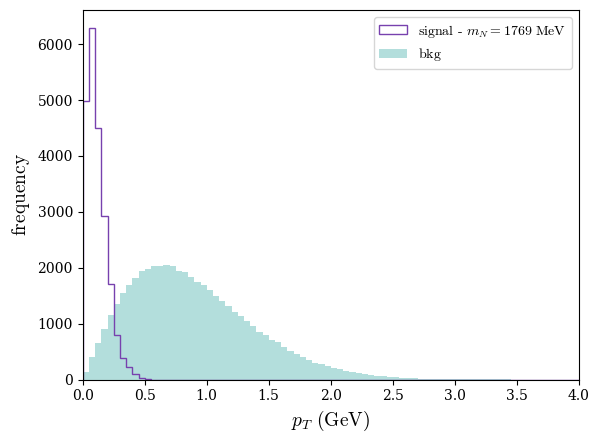

In [636]:
rango = 4
bines = 80

plt.hist(df_ds_signal_mpi_plot['1769']['pT'],label= r'$\text{signal - }m_N = 1769~\text{MeV}$', bins=bines, weights=1/10*bines/rango*df_ds_signal_mpi_plot['1769']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
plt.hist(df_plot_bkg_pim['pT'],label= r'$\text{bkg}$', bins=bines, weights=1/10000*norm_bkg*bines/rango*df_plot_bkg_pim['pS']/df_plot_bkg_pim['pS'], range=[0,rango], alpha=0.4, color="#41AEA9")
plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$p_T~\text{(GeV)}$', fontsize=14)
plt.xlim((0,rango))
plt.ylabel(r'$\text{frequency}$', fontsize=14)
#plt.yscale('log')
#plt.ylim((0,0.01))
plt.show()

In [607]:
todoS = 1.*df_ds_signal_mpi_plot['1769']['weight'].sum()
todoB = norm_bkg*len(df_plot_bkg_pim)

todoS, todoB, np.sqrt(2.44/todoS)*1e-6

(10984.258952720356, 2.43e+07, 1.4904229583378778e-08)

In [616]:
df_bkg_pim/2

,event,pdg,px,py,pz,E
0,0.0,6.5,0.007715,0.363518,0.457301,0.586617
1,0.0,105.5,-0.196542,-0.149670,0.029065,0.258350
2,0.5,6.5,-0.631090,-0.423583,5.263307,5.318166
3,0.5,105.5,0.643888,0.210204,0.900879,1.129261
4,1.0,6.5,-0.434955,0.730633,12.595837,12.624616
...,...,...,...,...,...,...
945705,577.5,105.5,-0.131885,0.274574,0.053144,0.316983
945706,578.0,6.5,0.471327,0.470316,8.848970,8.874143
945707,578.0,105.5,-0.218781,-0.168498,0.039172,0.287508
945708,578.5,6.5,-0.169544,-0.567970,6.733563,6.759808


In [617]:
len(df_bkg_pim)/2*norm_bkg

2.43e+07

In [618]:
len(df_bkg_pim)/2

4.73e+05

In [637]:
todoS = 1.*df_k_signal_mpi_plot['384']['weight'].sum()
todoB = norm_bkg*len(df_plot_bkg_pim)

todoS, todoB, np.sqrt(2.44/todoS)*1e-6

(219136598.5024355, 2.43e+07, 1.0552064935224432e-10)

In [643]:
1/(1.0552064935224432e-10/1.5171641420179117e-09)

14.377888605986321

In [642]:
1/9

0.1111111111111111

In [622]:
parteS = df_k_signal_mpi_plot['384'][(df_k_signal_mpi_plot['384']['pS']<0.24644895220644536) & (df_k_signal_mpi_plot['384']['DthetaS']<2.266170665587638)]['weight'].sum()
parteB = norm_bkg*len(df_plot_bkg_pim[(df_plot_bkg_pim['pS']<0.24644895220644536) & (df_plot_bkg_pim['DthetaS']<2.266170665587638)])

parteS/todoS*100, parteB/todoB*100, 100 - parteB/todoB*100

(99.98057416369116, 0.22628501337619353, 99.7737149866238)

In [512]:
parteS, parteB

(219094029.38551766, 5.50e+04)

In [504]:
np.sqrt(2.44/todoS)*1e-6

1.0552064935224432e-10

In [624]:
np.sqrt(4.61/2*np.sqrt(parteB)/parteS)*1e-6

1.570767790391903e-09

In [619]:
find_optimal_cuts_pS(df_k_signal_mpi_plot['384'], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 0.24644895220644536, 'DthetaS': 2.266170665587638},
 14799.967656086108,
 99.98057416369116,
 0.22628501337619353,
 5.50e+04,
 1.5171641420179117e-09)

In [625]:
find_optimal_cuts_pT(df_ds_signal_mpi_plot['1769'], df_plot_bkg_pim, 
                    pT_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='Ds', channel='mpi')

Starting grid search for optimal cuts...


({'pT': 0.1914078386919399, 'DthetaS': 0.17151649853688888},
 44.74410217489665,
 35.19195430738215,
 0.014803692463863127,
 3598.168,
 1.830738393694483e-07)

In [626]:
find_optimal_cuts_pS(df_ds_signal_mpi_plot['1769'], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='Ds', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 1.4304697333661667, 'DthetaS': 0.17151649853688888},
 7.745211120079796,
 49.17797734421169,
 1.9790422010975879,
 4.81e+05,
 5.251799162897654e-07)

In [54]:
# rango = 4
# bines = 18

# plt.hist(df_k_signal_plot['212']['pT'],label= 'signal - pT', bins=bines, weights=bines/rango*df_k_signal_plot['212']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
# plt.hist(df_k_signal_plot['212']['pS'],label= 'signal - pS', bins=bines, weights=bines/rango*df_k_signal_plot['212']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
# plt.hist(df_plot_bkg['pS'],label= 'background - pS', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['pS']/df_plot_bkg['pS'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step', linestyle=':')
# plt.hist(df_plot_bkg['pT'],label= 'background - pT', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['pT']/df_plot_bkg['pT'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')
# plt.legend(ncol=1, loc='upper right')
# plt.xlabel(r'$p_i$ (GeV)')
# #plt.xlim((0,4))
# plt.ylabel(r'frequency')
# plt.yscale('log')
# #plt.ylim((0,0.01))
# plt.show()

In [55]:
# rango = 4
# bines = 18

# plt.hist(df_k_signal_plot['369']['pT'],label= 'signal - pT', bins=bines, weights=bines/rango*df_k_signal_plot['369']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
# plt.hist(df_k_signal_plot['369']['pS'],label= 'signal - pS', bins=bines, weights=bines/rango*df_k_signal_plot['369']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
# plt.hist(df_plot_bkg['pS'],label= 'background - pS', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['pS']/df_plot_bkg['pS'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step', linestyle=':')
# plt.hist(df_plot_bkg['pT'],label= 'background - pT', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['pT']/df_plot_bkg['pT'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')
# plt.legend(ncol=1, loc='upper right')
# plt.xlabel(r'$p_i$ (GeV)')
# #plt.xlim((0,4))
# plt.ylabel(r'frequency')
# plt.yscale('log')
# #plt.ylim((0,0.01))
# plt.show()

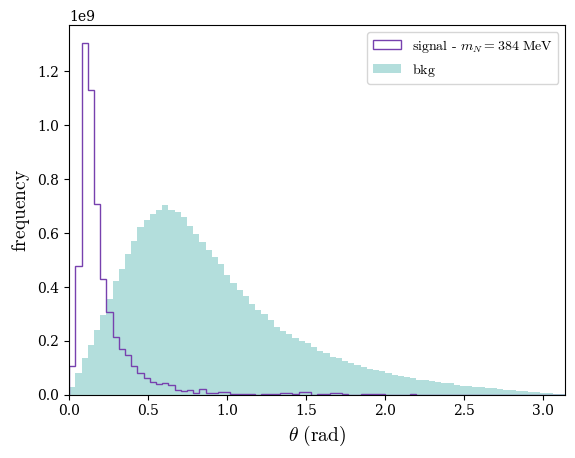

In [629]:
rango = np.pi
bines = 80

#plt.hist(df_k_signal_mpi_plot['384']['Dtheta'],label= 'signal - Delta', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
plt.hist(df_k_signal_mpi_plot['384']['DthetaS'],label= r'$\text{signal - }m_N = 384~\text{MeV}$', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
#plt.hist(df_plot_bkg_pim['Dtheta'],label= 'background - Dtheta', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg_pim['Dtheta']/df_plot_bkg_pim['Dtheta'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')
plt.hist(df_plot_bkg_pim['DthetaS'],label= r'$\text{bkg}$', bins=bines, weights=30*norm_bkg*bines/rango*df_plot_bkg_pim['DthetaS']/df_plot_bkg_pim['DthetaS'], range=[0,rango], alpha=0.4, color="#41AEA9")

plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$\theta~\text{(rad)}$', fontsize=14)
plt.xlim((0,rango))
plt.ylabel(r'$\text{frequency}$', fontsize=14)
#plt.yscale('log')
#plt.ylim((1e-16,1e-9))
plt.show()

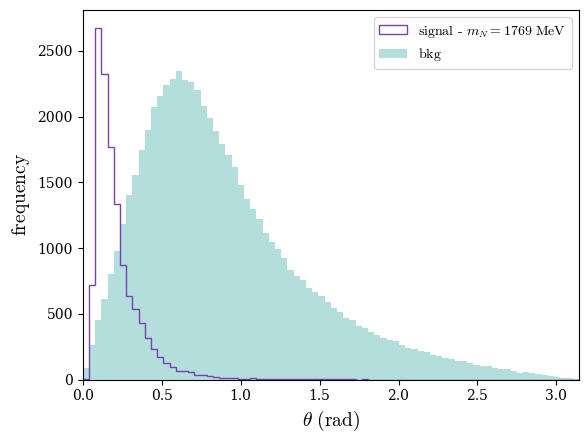

In [633]:
rango = np.pi
bines = 80

#plt.hist(df_k_signal_mpi_plot['384']['Dtheta'],label= 'signal - Delta', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
plt.hist(df_d_signal_mpi_plot['1745']['DthetaS'],label= r'$\text{signal - }m_N = 1769~\text{MeV}$', bins=bines, weights=bines/rango*df_d_signal_mpi_plot['1745']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
#plt.hist(df_plot_bkg_pim['Dtheta'],label= 'background - Dtheta', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg_pim['Dtheta']/df_plot_bkg_pim['Dtheta'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')
plt.hist(df_plot_bkg_pim['DthetaS'],label= r'$\text{bkg}$', bins=bines, weights=1/10000*norm_bkg*bines/rango*df_plot_bkg_pim['DthetaS']/df_plot_bkg_pim['DthetaS'], range=[0,rango], alpha=0.4, color="#41AEA9")

plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$\theta~\text{(rad)}$', fontsize=14)
plt.xlim((0,rango))
plt.ylabel(r'$\text{frequency}$', fontsize=14)
#plt.yscale('log')
#plt.ylim((1e-16,1e-9))
plt.show()

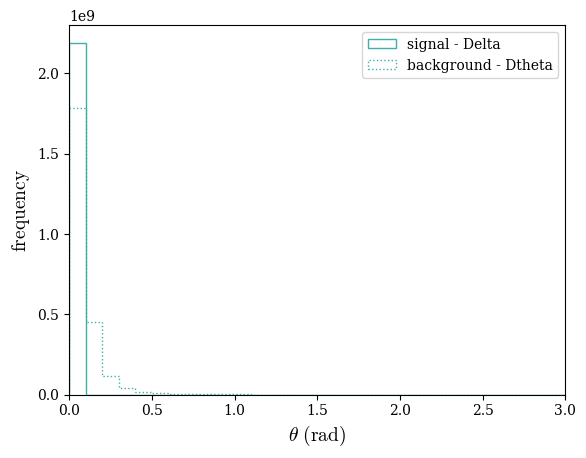

In [534]:
rango = 3
bines = 30

plt.hist(df_k_signal_mpi_plot['384']['Dtheta'],label= 'signal - Delta', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
#plt.hist(df_k_signal_mpi_plot['384']['DthetaS'],label= 'signal - DeltaS', bins=bines, weights=bines/rango*df_k_signal_mpi_plot['384']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
plt.hist(df_plot_bkg_pim['Dtheta'],label= 'background - Dtheta', bins=bines, weights=10*norm_bkg*bines/rango*df_plot_bkg_pim['Dtheta']/df_plot_bkg_pim['Dtheta'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')
#plt.hist(df_plot_bkg_pim['Dtheta'],label= 'background - Dtheta', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg_pim['Dtheta']/df_plot_bkg_pim['Dtheta'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step', linestyle=':')

plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$\theta~\text{(rad)}$', fontsize=14)
plt.xlim((0,rango))
plt.ylabel(r'$\text{frequency}$', fontsize=14)
#plt.yscale('log')
#plt.ylim((1e-16,1e-9))
plt.show()

In [58]:
# rango = 3
# bines = 30

# plt.hist(df_k_signal_plot['212']['Dtheta'],label= 'signal - Delta', bins=bines, weights=bines/rango*df_k_signal_plot['212']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
# plt.hist(df_k_signal_plot['212']['DthetaS'],label= 'signal - DeltaS', bins=bines, weights=bines/rango*df_k_signal_plot['212']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
# plt.hist(df_plot_bkg['DthetaS'],label= 'background - DthetaS', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['DthetaS']/df_plot_bkg['DthetaS'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step', linestyle=':')
# plt.hist(df_plot_bkg['Dtheta'],label= 'background - Dtheta', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['Dtheta']/df_plot_bkg['Dtheta'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')

# plt.legend(ncol=1, loc='upper right')
# plt.xlabel(r'$\theta$ (rad)')
# plt.xlim((0,rango))
# plt.ylabel(r'frequency')
# plt.yscale('log')
# #plt.ylim((1e-16,1e-9))
# plt.show()

In [59]:
# rango = 3
# bines = 10

# plt.hist(df_k_signal_plot['369']['Dtheta'],label= 'signal - Delta', bins=bines, weights=bines/rango*df_k_signal_plot['369']['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
# plt.hist(df_k_signal_plot['369']['DthetaS'],label= 'signal - DeltaS', bins=bines, weights=bines/rango*df_k_signal_plot['369']['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
# plt.hist(df_plot_bkg['DthetaS'],label= 'background - DthetaS', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['DthetaS']/df_plot_bkg['DthetaS'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step', linestyle=':')
# plt.hist(df_plot_bkg['Dtheta'],label= 'background - Dtheta', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['Dtheta']/df_plot_bkg['Dtheta'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')

# plt.legend(ncol=1, loc='upper right')
# plt.xlabel(r'$\theta$ (rad)')
# plt.xlim((0,rango))
# plt.ylabel(r'frequency')
# plt.yscale('log')
# #plt.ylim((1e-16,1e-9))
# plt.show()

In [338]:
#import numpy as np
from scipy.optimize import minimize_scalar, brentq

def compute_chi2_minimized(S, B, sigma_alpha=0.20):
    """Calculates chi2 minimized over the nuisance parameter alpha."""
    N_obs = B  # Asimov dataset assumption for sensitivity
    
    def chi2_func(alpha):
        N_exp = (1 + alpha) * (S + B)
        if N_exp <= 0: return 1e10
        
        # Poisson Likelihood Ratio
        stat_term = 0
        if N_obs > 0:
            stat_term = 2 * (N_exp - N_obs + N_obs * np.log(N_obs / N_exp))
        else:
            stat_term = 2 * N_exp
            
        pull_term = (alpha / sigma_alpha)**2
        return stat_term + pull_term

    res = minimize_scalar(chi2_func, bounds=(-0.99, 2.0), method='bounded')
    return res.fun

def get_mixing_limit_sigma(s_ref, b, sigma_alpha=0.20, target_chi2=4.61):
    """
    Finds the value of mixing**2 (u_sq) that reaches the target chi2.
    s_ref: Expected signal at mixing**2 = 1e-6
    """
    
    def root_func(u_sq):
        # Signal scales as (|U|^2 / 1e-6)^2
        S = s_ref * (u_sq / 1e-6)**2
        return compute_chi2_minimized(S, b, sigma_alpha) - target_chi2

    # We search for u_sq between a tiny value and a large value (e.g., 1.0)
    # Adjust brackets if your expected limit is extremely small or large
    try:
        limit = brentq(root_func, 1e-12, 1.0, xtol=1e-15)
        return limit
    except ValueError:
        return None # Could not find limit in this range

In [339]:
# --- Example Execution ---
# Suppose at a specific mass, your simulation gives:
S_at_1e_minus_6 = 0.5  # Signal events if mixing^2 was 10^-6
B_events = 10.0        # SM Background events
flux_uncert = 0.20     # 20%

u_sq_limit = get_mixing_limit_sigma(S_at_1e_minus_6, B_events, flux_uncert)

if u_sq_limit:
    print(f"90% CL Limit (2 DOF) on |U|^2: {u_sq_limit:.4e}")
else:
    print("Limit not found in range.")

90% CL Limit (2 DOF) on |U|^2: 4.9817e-06


In [340]:
get_mixing_limit_sigma(S_at_1e_minus_6, 0, flux_uncert)

2.2010707350053374e-06

In [573]:
from scipy.optimize import root_scalar
def solve_for_th2(Sf, Bf):
    # The target value for the significance expression
    target = 4.61 / 2.0
    
    # Define the function f(s) = (s+b)ln(1+s/b) - s - target
    def func(s):
        if s <= 0: return -target
        return (s + Bf) * np.log(1 + s/Bf) - s - target

    # Solve for s numerically (s must be positive)
    # Bracket [1e-9, 1e9] is usually safe for physics limits
    sol = root_scalar(func, bracket=[1e-9, 1e12])
    s_val = sol.root
    
    # Solve for th2: s = Sf * (th2/1e-6)**2
    th2 = 1e-6 * np.sqrt(s_val / Sf)
    return th2

import numpy as np
from scipy.optimize import minimize_scalar, brentq

def compute_chi2_minimized(S, B, sigma_alpha=0.20):
    """Calculates chi2 minimized over the nuisance parameter alpha."""
    N_obs = B  # Asimov dataset assumption for sensitivity
    
    def chi2_func(alpha):
        alpha = 0
        N_exp = (1 + alpha) * (S + B)
        if N_exp <= 0: return 1e10
        
        # Poisson Likelihood Ratio
        stat_term = 0
        if N_obs > 0:
            stat_term = 2 * (N_exp - N_obs + N_obs * np.log(N_obs / N_exp))
            stat_term = 2 * (N_obs - N_exp + N_exp * np.log(N_exp / N_obs))
        else:
            stat_term = 2 * N_exp
            
        pull_term = (alpha / sigma_alpha)**2
        return stat_term + pull_term
    
    res = minimize_scalar(chi2_func, bounds=(-0.99, 2.0), method='bounded')
    return res.fun

def get_mixing_limit(s_ref, b, sigma_alpha=0.20, target_chi2=4.61):
    """
    Finds the value of mixing**2 (u_sq) that reaches the target chi2.
    s_ref: Expected signal at mixing**2 = 1e-6
    """
    
    def root_func(u_sq):
        # Signal scales as (|U|^2 / 1e-6)^2
        S = s_ref * (u_sq / 1e-6)**2
        return compute_chi2_minimized(S, b, sigma_alpha) - target_chi2

    # We search for u_sq between a tiny value and a large value (e.g., 1.0)
    # Adjust brackets if your expected limit is extremely small or large
    try:
        limit = brentq(root_func, 1e-12, 1.0, xtol=1e-15)
        return limit
    except ValueError:
        return None # Could not find limit in this range

# # --- Example Execution ---
# # Suppose at a specific mass, your simulation gives:
# S_at_1e_minus_6 = 0.5  # Signal events if mixing^2 was 10^-6
# B_events = 10.0        # SM Background events
# flux_uncert = 0.20     # 20%

# u_sq_limit = get_mixing_limit(S_at_1e_minus_6, B_events, flux_uncert)

# if u_sq_limit:
#     print(f"90% CL Limit (2 DOF) on |U|^2: {u_sq_limit:.4e}")
# else:
#     print("Limit not found in range.")
 
def find_optimal_cuts_pS(df_sig, df_bkg, pS_direction='less', DthetaS_direction='less', 
                      sig_weight_col='weight', bkg_norm_factor=51.3, grid_size=50, meson='D', channel='mpi'):
    """
    Finds the optimal cuts on pS and DthetaS to maximize S / sqrt(S + B).
    Accounts for signal weights and a constant background normalization factor.
    """
    total_signal_weight = df_sig[sig_weight_col].sum()
    #total_bkg_events = len(df_bkg) * bkg_norm_factor
    #print(f"Total signal weight: {total_signal_weight:.2e}")
    if channel == 'mpi':    
        if meson == 'K':
            total_bkg_events = len(df_bkg) * bkg_norm_factor
        else:
            if meson == 'D':
                total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_d_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_d_p_mpi_fun(df_sig['MN'].iloc[0]))/(Nev_ds_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_ds_p_mpi_fun(df_sig['MN'].iloc[0]))
            else:
                if meson == 'Ds':
                    if df_sig['MN'].iloc[0] <= df_signal_mpi_d_p['mass'].max():
                        total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_ds_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_ds_p_mpi_fun(df_sig['MN'].iloc[0]))/(Nev_d_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_d_p_mpi_fun(df_sig['MN'].iloc[0]))
                    else:
                        total_bkg_events = len(df_bkg) * bkg_norm_factor
    if channel == 'vmm':
        if meson == 'K':
            total_bkg_events = len(df_bkg) * bkg_norm_factor
        else:
            if meson == 'D':
                total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_d_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_d_p_vmm_fun(df_sig['MN'].iloc[0]))/(Nev_ds_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_ds_p_vmm_fun(df_sig['MN'].iloc[0]))
            else:
                if meson == 'Ds':
                    if df_sig['MN'].iloc[0] <= df_signal_mpi_d_p['mass'].max():
                        total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_ds_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_ds_p_vmm_fun(df_sig['MN'].iloc[0]))/(Nev_d_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_d_p_vmm_fun(df_sig['MN'].iloc[0]))
                    else:
                        total_bkg_events = len(df_bkg) * bkg_norm_factor

    #print(f"Total background events (after normalization): {total_bkg_events:.2

    print("Starting grid search for optimal cuts...")
    
    # Determine the search ranges based on the data 
    pS_min = min(df_sig['pS'].quantile(0.01), df_bkg['pS'].quantile(0.01))
    pS_max = max(df_sig['pS'].quantile(1), df_bkg['pS'].quantile(1))
    
    # pT_min = min(df_sig['pT'].quantile(0.01), df_bkg['pT'].quantile(0.01))
    # pT_max = max(df_sig['pT'].quantile(1), df_bkg['pT'].quantile(1))

    DthetaS_min = min(df_sig['DthetaS'].quantile(0.01), df_bkg['DthetaS'].quantile(0.01))
    DthetaS_max = max(df_sig['DthetaS'].quantile(1), df_bkg['DthetaS'].quantile(1))
    
    # Create the grid
    pS_cuts = np.linspace(pS_min, pS_max, grid_size)
    # pT_cuts = np.linspace(pT_min, pT_max, grid_size)
    DthetaS_cuts = np.linspace(DthetaS_min, DthetaS_max, grid_size)
    
    best_significance = 0
    best_cuts = {'pS': None, 'DthetaS': None}
    
    # Extract underlying numpy arrays for speed
    sig_pS, sig_DthetaS = df_sig['pS'].values, df_sig['DthetaS'].values
    bkg_pS, bkg_DthetaS = df_bkg['pS'].values, df_bkg['DthetaS'].values
    
    # Extract signal weights
    if sig_weight_col not in df_sig.columns:
        raise ValueError(f"Weight column '{sig_weight_col}' not found in signal dataframe.")
    sig_weights = df_sig[sig_weight_col].values
    
    # Iterate through the grid
    best_significance = 0
    for pS_cut in pS_cuts:
        for DthetaS_cut in DthetaS_cuts:
            
            # 1. Apply pS cut
            if pS_direction == 'greater':
                sig_pass_pS = sig_pS > pS_cut
                bkg_pass_pS = bkg_pS > pS_cut
            else:
                sig_pass_pS = sig_pS < pS_cut
                bkg_pass_pS = bkg_pS < pS_cut
                
            # 2. Apply DthetaS cut
            if DthetaS_direction == 'greater':
                sig_pass_DthetaS = sig_DthetaS > DthetaS_cut
                bkg_pass_DthetaS = bkg_DthetaS > DthetaS_cut
            else:
                sig_pass_DthetaS = sig_DthetaS < DthetaS_cut
                bkg_pass_DthetaS = bkg_DthetaS < DthetaS_cut
            
            # Combine cuts (Logical AND)
            sig_pass = sig_pass_pS & sig_pass_DthetaS
            bkg_pass = bkg_pass_pS & bkg_pass_DthetaS
            
            # Calculate S (summing weights of passing signal events)
            S = np.sum(sig_weights[sig_pass])
            
            # Calculate B (counting passing bkg events and scaling by normalization factor)
            B = np.sum(bkg_pass) * bkg_norm_factor
            #B = len(bkg_pass) * bkg_norm_factor
            
            # Calculate Significance
            if S + B > 0:
                significance = S / np.sqrt(S + B)
            else:
                significance = 0
                
            # Update best cuts if current significance is higher
            if significance > best_significance:
                best_significance = significance
                best_cuts = {'pS': pS_cut, 'DthetaS': DthetaS_cut}

    # After finding the best cuts, calculate final S, B, and th2_v for those cuts
    pSf = best_cuts['pS']
    DthetaSf = best_cuts['DthetaS']
    S_df = df_sig[(df_sig['pS']<pSf) & (df_sig['DthetaS']<DthetaSf)]
    Sf = S_df[sig_weight_col].sum()
    Bf = len(df_bkg[(df_bkg['pS']<pSf) & (df_bkg['DthetaS']<DthetaSf)].reset_index(drop=True)) * bkg_norm_factor
    # if Bf == 0:
    #     th2_v = (1e-6)*np.sqrt(2.44/Sf)
    # else:
    #     #th2_v = get_mixing_limit(Sf, Bf, sigma_alpha=20/100, target_chi2=4.61)
    #     th2_v = solve_for_th2(Sf, Bf)
    #th2_v = solve_for_th2(Sf, Bf)
    th2_v = get_mixing_limit(Sf, Bf, sigma_alpha=20/10000, target_chi2=4.61)
    # if Bf == 0:
    #     th2_v = (1e-6)*np.sqrt(2.44/Sf)
    # #     Bf = 1
    # else:
    #     if Bf/Sf < 0.5:
    #         #chi2 = 2 * ((Sf + Bf) * np.log(1 + Sf/Bf) - Sf)
    #         th2_v = solve_for_th2(Sf, Bf)
    #         #chi2t = (Sf**2) / Bf
    #     else:
    #         #chi2 = chi2t = (Sf**2) / Bf
    #         th2_v = (1e-6)*np.sqrt(np.sqrt(4.61*Bf)/Sf)
                
    return best_cuts, best_significance, Sf/total_signal_weight*100, Bf/total_bkg_events*100, Bf, th2_v # chi2, chi2t, th2_v

In [574]:
def find_optimal_cuts_pT(df_sig, df_bkg, pT_direction='less', DthetaS_direction='less', 
                      sig_weight_col='weight', bkg_norm_factor=51.3, grid_size=50, meson='D', channel='mpi'):
    """
    Finds the optimal cuts on pT and DthetaS to maximize S / sqrt(S + B).
    Accounts for signal weights and a constant background normalization factor.
    """
    total_signal_weight = df_sig[sig_weight_col].sum()
    #total_bkg_events = len(df_bkg) * bkg_norm_factor
    #print(f"Total signal weight: {total_signal_weight:.2e}")
    if channel == 'mpi':    
        if meson == 'K':
            total_bkg_events = len(df_bkg) * bkg_norm_factor
        else:
            if meson == 'D':
                total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_d_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_d_p_mpi_fun(df_sig['MN'].iloc[0]))/(Nev_ds_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_ds_p_mpi_fun(df_sig['MN'].iloc[0]))
            else:
                if meson == 'Ds':
                    if df_sig['MN'].iloc[0] <= df_signal_mpi_d_p['mass'].max():
                        total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_ds_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_ds_p_mpi_fun(df_sig['MN'].iloc[0]))/(Nev_d_m_mpi_fun(df_sig['MN'].iloc[0])+Nev_d_p_mpi_fun(df_sig['MN'].iloc[0]))
                    else:
                        total_bkg_events = len(df_bkg) * bkg_norm_factor
    if channel == 'vmm':
        if meson == 'K':
            total_bkg_events = len(df_bkg) * bkg_norm_factor
        else:
            if meson == 'D':
                total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_d_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_d_p_vmm_fun(df_sig['MN'].iloc[0]))/(Nev_ds_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_ds_p_vmm_fun(df_sig['MN'].iloc[0]))
            else:
                if meson == 'Ds':
                    if df_sig['MN'].iloc[0] <= df_signal_mpi_d_p['mass'].max():
                        total_bkg_events = len(df_bkg) * bkg_norm_factor * (Nev_ds_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_ds_p_vmm_fun(df_sig['MN'].iloc[0]))/(Nev_d_m_vmm_fun(df_sig['MN'].iloc[0])+Nev_d_p_vmm_fun(df_sig['MN'].iloc[0]))
                    else:
                        total_bkg_events = len(df_bkg) * bkg_norm_factor

    #print(f"Total background events (after normalization): {total_bkg_events:.2

    print("Starting grid search for optimal cuts...")
    
    # Determine the search ranges based on the data 
    pT_min = min(df_sig['pT'].quantile(0.01), df_bkg['pT'].quantile(0.01))
    pT_max = max(df_sig['pT'].quantile(1), df_bkg['pT'].quantile(1))
    
    # pT_min = min(df_sig['pT'].quantile(0.01), df_bkg['pT'].quantile(0.01))
    # pT_max = max(df_sig['pT'].quantile(1), df_bkg['pT'].quantile(1))

    DthetaS_min = min(df_sig['DthetaS'].quantile(0.01), df_bkg['DthetaS'].quantile(0.01))
    DthetaS_max = max(df_sig['DthetaS'].quantile(1), df_bkg['DthetaS'].quantile(1))
    
    # Create the grid
    pT_cuts = np.linspace(pT_min, pT_max, grid_size)
    # pT_cuts = np.linspace(pT_min, pT_max, grid_size)
    DthetaS_cuts = np.linspace(DthetaS_min, DthetaS_max, grid_size)
    
    best_significance = 0
    best_cuts = {'pT': None, 'DthetaS': None}
    
    # Extract underlying numpy arrays for speed
    sig_pT, sig_DthetaS = df_sig['pT'].values, df_sig['DthetaS'].values
    bkg_pT, bkg_DthetaS = df_bkg['pT'].values, df_bkg['DthetaS'].values
    
    # Extract signal weights
    if sig_weight_col not in df_sig.columns:
        raise ValueError(f"Weight column '{sig_weight_col}' not found in signal dataframe.")
    sig_weights = df_sig[sig_weight_col].values
    
    # Iterate through the grid
    best_significance = 0
    for pT_cut in pT_cuts:
        for DthetaS_cut in DthetaS_cuts:
            
            # 1. Apply pT cut
            if pT_direction == 'greater':
                sig_pass_pT = sig_pT > pT_cut
                bkg_pass_pT = bkg_pT > pT_cut
            else:
                sig_pass_pT = sig_pT < pT_cut
                bkg_pass_pT = bkg_pT < pT_cut
                
            # 2. Apply DthetaS cut
            if DthetaS_direction == 'greater':
                sig_pass_DthetaS = sig_DthetaS > DthetaS_cut
                bkg_pass_DthetaS = bkg_DthetaS > DthetaS_cut
            else:
                sig_pass_DthetaS = sig_DthetaS < DthetaS_cut
                bkg_pass_DthetaS = bkg_DthetaS < DthetaS_cut
            
            # Combine cuts (Logical AND)
            sig_pass = sig_pass_pT & sig_pass_DthetaS
            bkg_pass = bkg_pass_pT & bkg_pass_DthetaS
            
            # Calculate S (summing weights of passing signal events)
            S = np.sum(sig_weights[sig_pass])
            
            # Calculate B (counting passing bkg events and scaling by normalization factor)
            B = np.sum(bkg_pass) * bkg_norm_factor
            #B = len(bkg_pass) * bkg_norm_factor
            
            # Calculate Significance
            if S + B > 0:
                significance = S / np.sqrt(S + B)
            else:
                significance = 0
                
            # Update best cuts if current significance is higher
            if significance > best_significance:
                best_significance = significance
                best_cuts = {'pT': pT_cut, 'DthetaS': DthetaS_cut}

    # After finding the best cuts, calculate final S, B, and th2_v for those cuts
    pTf = best_cuts['pT']
    DthetaSf = best_cuts['DthetaS']
    S_df = df_sig[(df_sig['pT']<pTf) & (df_sig['DthetaS']<DthetaSf)]
    Sf = S_df[sig_weight_col].sum()
    Bf = len(df_bkg[(df_bkg['pT']<pTf) & (df_bkg['DthetaS']<DthetaSf)].reset_index(drop=True)) * bkg_norm_factor
    # if Bf == 0:
    #     th2_v = (1e-6)*np.sqrt(2.44/Sf)
    # else:
    #     #th2_v = get_mixing_limit(Sf, Bf, sigma_alpha=20/100, target_chi2=4.61)
    #     th2_v = solve_for_th2(Sf, Bf)
    #th2_v = solve_for_th2(Sf, Bf)
    th2_v = get_mixing_limit(Sf, Bf, sigma_alpha=20/10000, target_chi2=4.61)
    return best_cuts, best_significance, Sf/total_signal_weight*100, Bf/total_bkg_events*100, Bf, th2_v # chi2, chi2t, th2_v

In [121]:
df_k_signal_mpi_plot['384']

,M_weight,N_weight,MN,USQUARED,L_lab_N,x_0,y_0,z_0,thetaN,phiN,...,dist_to_enter,dist_in_det,x_final,y_final,z_final,weight,pT,pS,Dtheta,DthetaS
0,300.000,0.000144,0.384,0.000001,168080.0,0.371961,-0.264560,6.00091,0.003482,1.580400,...,570.473741,5.025659,2.368850,-0.283738,579.449996,183987.901819,0.003083,0.206376,0.003482,0.638513
1,272.727,0.000040,0.384,0.000001,609137.0,0.106866,0.237710,42.09730,0.002483,1.984030,...,534.376697,5.026135,1.323428,-0.295730,577.138146,46273.894691,0.007965,0.122095,0.002483,0.200341
2,245.455,0.000017,0.384,0.000001,1403160.0,-0.394449,-0.080660,64.01040,0.001739,-0.973821,...,512.390237,5.025121,-1.134961,0.422670,578.931402,18085.204161,0.012850,0.206237,0.001739,0.078954
3,245.455,0.000031,0.384,0.000001,783523.0,-0.041672,-0.078020,10.73180,0.006096,-2.057090,...,565.892458,0.525458,-3.093054,-1.691093,576.914926,3385.448538,0.025155,0.176001,0.006096,0.138148
4,225.000,0.000035,0.384,0.000001,687790.0,0.125775,0.231104,11.82540,0.003768,2.307610,...,564.742524,5.026937,1.707371,-1.203820,578.637969,33817.652441,0.013647,0.199027,0.003768,0.168202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110776,4.000,0.000005,0.384,0.000001,4640360.0,-0.320507,-0.120224,106.61000,0.002582,-1.665990,...,469.857881,5.025753,-1.538662,-0.236536,580.617439,205.491265,0.063090,0.148508,0.002582,0.022680
110777,4.000,0.000004,0.384,0.000001,5882920.0,0.047910,-0.019302,8.70768,0.005673,1.882030,...,567.845834,5.026577,3.116829,-1.006537,576.982681,162.115825,0.175760,0.235082,0.005673,0.017656
110778,4.000,0.000005,0.384,0.000001,5232890.0,-0.035237,0.327714,99.81100,0.002385,-0.014873,...,478.768200,2.740646,-0.052269,1.472768,579.975611,99.370973,0.065728,0.137166,0.002385,0.021601
110779,4.000,0.000003,0.384,0.000001,8777220.0,0.003862,-0.008148,2.78587,0.005104,2.167160,...,573.831579,0.885921,2.428627,-1.654107,576.980990,19.151275,0.235928,0.257621,0.005104,0.012501


In [356]:
df_plot_bkg_pim[df_plot_bkg_pim['DthetaS'] == df_plot_bkg_pim['DthetaS'].max()].index[0]

116626

In [384]:
testeo = df_plot_bkg_vmm[df_plot_bkg_vmm[df_plot_bkg_vmm['DthetaS'] == df_plot_bkg_vmm['DthetaS'].max()].index[0]:df_plot_bkg_vmm[df_plot_bkg_vmm['DthetaS'] == df_plot_bkg_vmm['DthetaS'].max()].index[0]+1]
testeo

,event,pdg,px,py,pz,E,pT,pS,Dtheta,DthetaS
3,0.0,13.0,-1.635484,0.031274,21.274774,21.337829,1.640996,1.636971,0.077498,2.717753


In [359]:
testeo = df_plot_bkg_pim[df_plot_bkg_pim[df_plot_bkg_pim['DthetaS'] == df_plot_bkg_pim['DthetaS'].max()].index[0]:df_plot_bkg_pim[df_plot_bkg_pim['DthetaS'] == df_plot_bkg_pim['DthetaS'].max()].index[0]+1]

In [362]:
find_optimal_cuts(df_k_signal_mpi_plot['384'], testeo, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 0.43315147191336195, 'DthetaS': 2.266170665587638},
 14803.262138974353,
 99.99998697285429,
 0.0,
 0.0,
 1.0552065622540937e-10)

In [360]:
find_optimal_cuts(df_k_signal_mpi_plot['384'], testeo, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 0.43315147191336195, 'DthetaS': 2.266170665587638},
 14803.262138974353,
 99.99998697285429,
 0.0,
 0.0,
 1.0513838012461824e-10)

In [575]:
find_optimal_cuts_pS(df_k_signal_mpi_plot['384'], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 0.24644895220644536, 'DthetaS': 2.266170665587638},
 14799.967656086108,
 99.98057416369116,
 0.22628501337619353,
 5.50e+04,
 1.5171641420179117e-09)

In [541]:
find_optimal_cuts_pS(df_k_signal_mpi_plot['384'], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 0.24644895220644536, 'DthetaS': 2.266170665587638},
 14799.967656086108,
 99.98057416369116,
 0.22628501337619353,
 5.50e+04,
 1.5183221299010441e-09)

In [576]:
find_optimal_cuts_pT(df_k_signal_mpi_plot['384'], df_plot_bkg_pim, 
                    pT_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pT': 0.18458068724562585, 'DthetaS': 2.266170665587638},
 14771.370038871977,
 99.96963834709098,
 3.6214061393027457,
 8.80e+05,
 3.0329388882898648e-09)

In [543]:
find_optimal_cuts_pT(df_k_signal_mpi_plot['384'], df_plot_bkg_pim, 
                    pT_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pT': 0.18458068724562585, 'DthetaS': 2.266170665587638},
 14771.370038871977,
 99.96963834709098,
 3.6214061393027457,
 8.80e+05,
 3.0335173191243563e-09)

In [371]:
find_optimal_cuts(df_k_signal_mpi_plot['384'], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=30, meson='K', channel='mpi')

Starting grid search for optimal cuts...


({'pS': 0.24644895220644536, 'DthetaS': 2.266170665587638},
 14799.967656086108,
 99.98057416369116,
 0.22628501337619353,
 5.50e+04,
 1.3746044594279684e-08)

In [ ]:
df_plot_bkg_vmm

In [577]:
sol_k_vmm = pd.DataFrame(columns=['Mass', 'Ua2'])

for masa in df_k_signal_vmm_plot.keys():

    best_cuts, best_significance, S_norm, B_norm, Bf, u2_PS = find_optimal_cuts_pS(df_k_signal_vmm_plot[masa], df_plot_bkg_vmm, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=16, meson='K', channel='vmm')
    best_cuts, best_significance, S_norm, B_norm, Bf, u2_PT = find_optimal_cuts_pT(df_k_signal_vmm_plot[masa], df_plot_bkg_vmm, 
                    pT_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=16, meson='K', channel='vmm')
    u2 = min(u2_PS, u2_PT)
    sol = [np.log10(float(masa)/1e3), np.log10(float(u2))]
    sol_k_vmm = pd.concat([sol_k_vmm, pd.Series(sol, index=sol_k_vmm.columns).to_frame().T], ignore_index=True)

Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...


/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/1926915530.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sol_k_vmm = pd.concat([sol_k_vmm, pd.Series(sol, index=sol_k_vmm.columns).to_frame().T], ignore_index=True)


Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...


In [578]:
sol_d_vmm = pd.DataFrame(columns=['Mass', 'Ua2'])

for masa in df_d_signal_vmm_plot.keys():
    if float(masa) > float(list(df_k_signal_vmm_plot.keys())[-1]):
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PS = find_optimal_cuts_pS(df_d_signal_vmm_plot[masa], df_plot_bkg_vmm, 
                        pS_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=16, meson='D', channel='vmm')
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PT = find_optimal_cuts_pT(df_d_signal_vmm_plot[masa], df_plot_bkg_vmm, 
                        pT_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=16, meson='D', channel='vmm')
        u2 = min(u2_PS, u2_PT)
        sol = [np.log10(float(masa)/1e3), np.log10(float(u2))]
        sol_d_vmm = pd.concat([sol_d_vmm, pd.Series(sol, index=sol_d_vmm.columns).to_frame().T], ignore_index=True)

Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...


/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/2940889553.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sol_d_vmm = pd.concat([sol_d_vmm, pd.Series(sol, index=sol_d_vmm.columns).to_frame().T], ignore_index=True)


Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid se

In [579]:
sol_ds_vmm = pd.DataFrame(columns=['Mass', 'Ua2'])

for masa in df_ds_signal_vmm_plot.keys():
    if float(masa) > float(list(df_k_signal_vmm_plot.keys())[-1]):
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PS = find_optimal_cuts_pS(df_ds_signal_vmm_plot[masa], df_plot_bkg_vmm, 
                        pS_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=16, meson='Ds', channel='vmm')
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PT = find_optimal_cuts_pT(df_ds_signal_vmm_plot[masa], df_plot_bkg_vmm, 
                        pT_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=16, meson='Ds', channel='vmm')
        u2 = min(u2_PS, u2_PT)
        sol = [np.log10(float(masa)/1e3), np.log10(float(u2))]
        sol_ds_vmm = pd.concat([sol_ds_vmm, pd.Series(sol, index=sol_ds_vmm.columns).to_frame().T], ignore_index=True)

Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...


/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/637596700.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sol_ds_vmm = pd.concat([sol_ds_vmm, pd.Series(sol, index=sol_ds_vmm.columns).to_frame().T], ignore_index=True)


Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid se

In [580]:
gridsize = 30

sol_k_mpi = pd.DataFrame(columns=['Mass', 'Ua2'])

for masa in df_k_signal_mpi_plot.keys():

    best_cuts, best_significance, S_norm, B_norm, Bf, u2_PS = find_optimal_cuts_pS(df_k_signal_mpi_plot[masa], df_plot_bkg_pim, 
                    pS_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=gridsize, meson='K', channel='mpi')
    best_cuts, best_significance, S_norm, B_norm, Bf, u2_PT = find_optimal_cuts_pT(df_k_signal_mpi_plot[masa], df_plot_bkg_pim, 
                    pT_direction='less', DthetaS_direction='less', 
                    sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=gridsize, meson='K', channel='mpi')
    u2 = min(u2_PS, u2_PT) 
    sol = [np.log10(float(masa)/1e3), np.log10(float(u2))]
    sol_k_mpi = pd.concat([sol_k_mpi, pd.Series(sol, index=sol_k_mpi.columns).to_frame().T], ignore_index=True)
    
sol_d_mpi = pd.DataFrame(columns=['Mass', 'Ua2'])

for masa in df_d_signal_mpi_plot.keys():
    if float(masa) > float(list(df_k_signal_mpi_plot.keys())[-1]):
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PS = find_optimal_cuts_pS(df_d_signal_mpi_plot[masa], df_plot_bkg_pim, 
                        pS_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=gridsize, meson='D', channel='mpi')
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PT = find_optimal_cuts_pT(df_d_signal_mpi_plot[masa], df_plot_bkg_pim, 
                        pT_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=gridsize, meson='D', channel='mpi')
        u2 = min(u2_PS, u2_PT)
        sol = [np.log10(float(masa)/1e3), np.log10(float(u2))]
        sol_d_mpi = pd.concat([sol_d_mpi, pd.Series(sol, index=sol_d_mpi.columns).to_frame().T], ignore_index=True)

sol_ds_mpi = pd.DataFrame(columns=['Mass', 'Ua2'])

for masa in df_ds_signal_mpi_plot.keys():
    if float(masa) > float(list(df_k_signal_mpi_plot.keys())[-1]):
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PS = find_optimal_cuts_pS(df_ds_signal_mpi_plot[masa], df_plot_bkg_pim, 
                        pS_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=gridsize, meson='Ds', channel='mpi')
        best_cuts, best_significance, S_norm, B_norm, Bf, u2_PT = find_optimal_cuts_pT(df_ds_signal_mpi_plot[masa], df_plot_bkg_pim, 
                        pT_direction='less', DthetaS_direction='less', 
                        sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=gridsize, meson='Ds', channel='mpi')
        u2 = min(u2_PS, u2_PT)
        sol = [np.log10(float(masa)/1e3), np.log10(float(u2))]
        sol_ds_mpi = pd.concat([sol_ds_mpi, pd.Series(sol, index=sol_ds_mpi.columns).to_frame().T], ignore_index=True)

Starting grid search for optimal cuts...
Starting grid search for optimal cuts...


/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/3976211239.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sol_k_mpi = pd.concat([sol_k_mpi, pd.Series(sol, index=sol_k_mpi.columns).to_frame().T], ignore_index=True)


Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...


/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/3976211239.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sol_d_mpi = pd.concat([sol_d_mpi, pd.Series(sol, index=sol_d_mpi.columns).to_frame().T], ignore_index=True)


Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid se

/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/3976211239.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sol_ds_mpi = pd.concat([sol_ds_mpi, pd.Series(sol, index=sol_ds_mpi.columns).to_frame().T], ignore_index=True)


Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid search for optimal cuts...
Starting grid se

/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/322306128.py:11: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  segments_vmm = contour.allsegs[0]


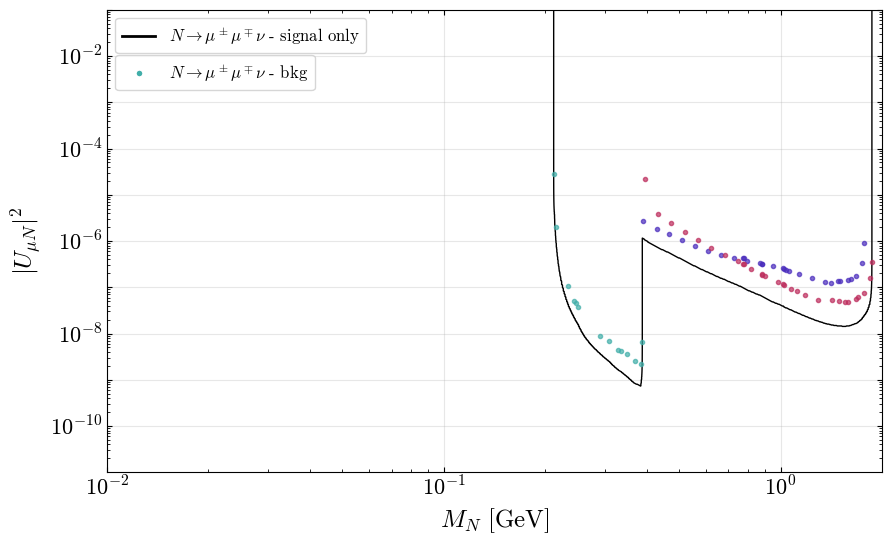

In [581]:
#m_unique = np.unique(grid_df['m'])
#u2_unique = np.unique(grid_df['u2'])
Nev_grid = grid_vmm_df.pivot_table(values='Nev', index='u2', columns='m', aggfunc='first')

# Create contour plot
fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contour(Nev_grid.columns, Nev_grid.index, Nev_grid.values, levels=[2.44], colors='black', linewidths=1)
# Extract the paths
# allsegs is a nested list: [level_index][segment_index]
# Since we only have one level, we use index 0.
segments_vmm = contour.allsegs[0]
ax.scatter(10**sol_k_vmm['Mass'], 10**sol_k_vmm['Ua2'], color='#41AEA9', label='Optimal cuts: K', zorder=5, alpha=0.7, marker='.')
ax.scatter(10**sol_d_vmm['Mass'], 10**sol_d_vmm['Ua2'], color="#4A2DBD", label='Optimal cuts: D', zorder=5, alpha=0.7, marker='.')
ax.scatter(10**sol_ds_vmm['Mass'], 10**sol_ds_vmm['Ua2'], color="#BD2D5D", label='Optimal cuts: Ds', zorder=5, alpha=0.7, marker='.')

#ax.clabel(contour, inline=True, fontsize=10)
# 1. Create the first legend (Contour/Line)
line_handle = [Line2D([0], [0], color='black', lw=2)]
line_label = [r'$N\to \mu^\pm\mu^\mp\nu~\text{- signal only}$']
leg1 = ax.legend(line_handle, line_label, loc='upper left', fontsize=12)

# 2. IMPORTANT: Add the first legend manually so it isn't overwritten
ax.add_artist(leg1)

# 3. Create the second legend (Scatter)
# Assuming 'sc' is your scatter plot object: sc = ax.scatter(...)
# If you haven't defined 'sc', you can use a Proxy Artist like this:
scatter_handle = [Line2D([0], [0], marker='.', color='w', 
                         markerfacecolor='#41AEA9', markersize=10)] 
scatter_label = [r'$N\to \mu^\pm\mu^\mp\nu~\text{- bkg}$']

ax.legend(scatter_handle, scatter_label, 
          loc='upper left', 
          bbox_to_anchor=(0, 0.92), # Adjust 0.92 based on your plot's aspect ratio
          fontsize=12,
          frameon=True)
# Customize ticks
ax = plt.gca()
# asp_fact=(np.log10(4)-np.log10(1e-3))/(np.log10(ymax)-np.log10(ymin))
# ax.set_aspect(asp_fact)
plt.xscale('log')
plt.yscale('log')

# The logic: hide labels if the log10 of the value is odd
def log_y_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    if exponent % 2 == 0:
        return f'$10^{{{exponent}}}$'
    else:
        return '' # Keep the tick, hide the label
    
def log_x_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    # if exponent % 2 == 0:
    #     return f'$10^{{{exponent}}}$'
    # else:
    #     return '' # Keep the tick, hide the label
    return f'$10^{{{exponent}}}$'

#ax.yaxis.set_major_formatter(plt.FuncFormatter(log_formatter))

# Show ticks on all four sides
ax.tick_params(top=True, right=True, which='both', direction='in')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_x_formatter))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_y_formatter))
ax.tick_params(axis='both', labelsize=16)

plt.xlabel(r'$M_N~[\text{GeV}]$', fontsize=18)
plt.ylabel(r'$|U_{\mu N}|^2$', fontsize=18)
plt.xlim(0.01, 2)
#plt.title(r'Contour at $N_{ev}$ = 2.61')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/7w/_gsxb3tj21jbhsc7jpbrd9k80000gn/T/ipykernel_75543/3165470279.py:11: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  segments_mpi = contour.allsegs[0]


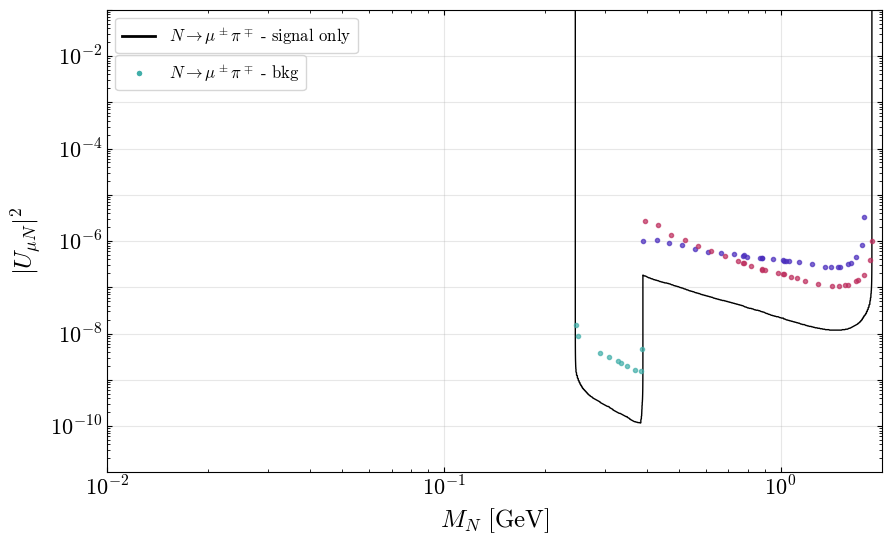

In [582]:
#m_unique = np.unique(grid_df['m'])
#u2_unique = np.unique(grid_df['u2'])
Nev_grid = grid_mpi_df.pivot_table(values='Nev', index='u2', columns='m', aggfunc='first')

# Create contour plot
fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contour(Nev_grid.columns, Nev_grid.index, Nev_grid.values, levels=[2.44], colors='black', linewidths=1)
# Extract the paths
# allsegs is a nested list: [level_index][segment_index]
# Since we only have one level, we use index 0.
segments_mpi = contour.allsegs[0]
ax.scatter(10**sol_k_mpi['Mass'], 10**sol_k_mpi['Ua2'], color='#41AEA9', label='Optimal cuts: K', zorder=5, alpha=0.7, marker='.')
ax.scatter(10**sol_d_mpi['Mass'], 10**sol_d_mpi['Ua2'], color="#4A2DBD", label='Optimal cuts: D', zorder=5, alpha=0.7, marker='.')
ax.scatter(10**sol_ds_mpi['Mass'], 10**sol_ds_mpi['Ua2'], color="#BD2D5D", label='Optimal cuts: Ds', zorder=5, alpha=0.7, marker='.')

#ax.clabel(contour, inline=True, fontsize=10)
# 1. Create the first legend (Contour/Line)
line_handle = [Line2D([0], [0], color='black', lw=2)]
line_label = [r'$N\to \mu^\pm\pi^\mp~\text{- signal only}$']
leg1 = ax.legend(line_handle, line_label, loc='upper left', fontsize=12)

# 2. IMPORTANT: Add the first legend manually so it isn't overwritten
ax.add_artist(leg1)

# 3. Create the second legend (Scatter)
# Assuming 'sc' is your scatter plot object: sc = ax.scatter(...)
# If you haven't defined 'sc', you can use a Proxy Artist like this:
scatter_handle = [Line2D([0], [0], marker='.', color='w', 
                         markerfacecolor='#41AEA9', markersize=10)] 
scatter_label = [r'$N\to \mu^\pm\pi^\mp~\text{- bkg}$']

ax.legend(scatter_handle, scatter_label, 
          loc='upper left', 
          bbox_to_anchor=(0, 0.92), # Adjust 0.92 based on your plot's aspect ratio
          fontsize=12,
          frameon=True)
# Customize ticks
ax = plt.gca()
# asp_fact=(np.log10(4)-np.log10(1e-3))/(np.log10(ymax)-np.log10(ymin))
# ax.set_aspect(asp_fact)
plt.xscale('log')
plt.yscale('log')

# The logic: hide labels if the log10 of the value is odd
def log_y_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    if exponent % 2 == 0:
        return f'$10^{{{exponent}}}$'
    else:
        return '' # Keep the tick, hide the label
    
def log_x_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    # if exponent % 2 == 0:
    #     return f'$10^{{{exponent}}}$'
    # else:
    #     return '' # Keep the tick, hide the label
    return f'$10^{{{exponent}}}$'

#ax.yaxis.set_major_formatter(plt.FuncFormatter(log_formatter))

# Show ticks on all four sides
ax.tick_params(top=True, right=True, which='both', direction='in')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_x_formatter))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_y_formatter))
ax.tick_params(axis='both', labelsize=16)

plt.xlabel(r'$M_N~[\text{GeV}]$', fontsize=18)
plt.ylabel(r'$|U_{\mu N}|^2$', fontsize=18)
plt.xlim(0.01, 2)
#plt.title(r'Contour at $N_{ev}$ = 2.61')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# m_grid = np.logspace(-2, np.log10(2), 200)
# U2_s_only = 1e-7*((m_grid-1.2)**2+0.1)

# m_sb_points = np.array([0.3, 0.6, 1.0, 1.5, 1.8])

# true_penalty_log10 = 1.5 - 0.5*m_sb_points + np.random.normal(0, 0.1, len(m_sb_points))

# U2_s_only_at_points = np.interp(m_sb_points, m_grid, U2_s_only)

# U2_sb_points = U2_s_only_at_points * 10**true_penalty_log10

In [583]:
sorted_data_vmm = segments_vmm[segments_vmm[:, 0].argsort()]
sorted_data_mpi = segments_mpi[segments_mpi[:, 0].argsort()]

In [584]:
m_grid_vmm = sorted_data_vmm[:, 0]
U2_s_only_vmm = sorted_data_vmm[:, 1]

m_grid_mpi = sorted_data_mpi[:, 0]
U2_s_only_mpi = sorted_data_mpi[:, 1]


# m_kaon = 0.493677
# m_muon = 0.105658
# threshold = m_kaon - m_muon

# m_grid_k = m_grid[m_grid <= threshold+1e-2]
# U2_s_only_k = U2_s_only[:len(m_grid_k)]
# len(m_grid_k), len(U2_s_only_k)

# m_grid_d = m_grid[m_grid > threshold+8e-3]
# U2_s_only_d = U2_s_only[:len(m_grid_d)]
# len(m_grid_d), len(U2_s_only_d)

In [585]:
# m_grid = segments[:, 0]
# U2_s_only = segments[:, 1]

# #m_sb_points = np.concatenate((10**sol_k_mpi['Mass'].to_numpy(), 10**sol_d_mpi['Mass'].to_numpy(), 10**sol_ds_mpi['Mass'].to_numpy()))

# m_sb_points_k = 10**sol_k_mpi['Mass'].to_numpy()

# true_penalty_log10_k = 2.0 - 0.5*m_sb_points_k + np.random.normal(0, 0.1, len(m_sb_points_k))

# U2_s_only_at_points_k = np.interp(m_sb_points_k, m_grid_k, U2_s_only_k)
# #U2_sb_points_k = U2_s_only_at_points_k * 10**true_penalty_log10_k
# U2_sb_points_k = 10**sol_k_mpi['Ua2'].to_numpy()
# # Step 1: Evaluate the S-only template at the S+B mass points
# # (We use linear interpolation here assuming the grid is dense enough)
# U2_template_at_points_k = np.interp(m_sb_points_k, m_grid_k, U2_s_only_k)
# # Step 2: Calculate the log10 ratio (penalty factor) for the discrete points
# # R_i = log10(U2_sb_i) - log10(U2_0(m_i))
# log_ratio_points_k = np.log10(U2_sb_points_k) - np.log10(U2_template_at_points_k)

# # Step 3: Fit a low-order polynomial to the log ratio
# # We use a 2nd-order (quadratic) polynomial here
# degree = 1
# poly_coeffs = np.polyfit(m_sb_points_k, log_ratio_points_k, degree)
# poly_function = np.poly1d(poly_coeffs)

# # Step 4: Evaluate the fitted polynomial over the full continuous mass grid
# log_ratio_continuous = poly_function(m_grid_k)

# # Step 5: Reconstruct the continuous S+B contour
# # U2_sb(m) = U2_0(m) * 10^(R(m))
# U2_sb_continuous_k = U2_s_only_k * 10**(log_ratio_continuous)


# # ####  

# m_sb_points_d = np.concatenate((10**sol_k_mpi['Mass'].to_numpy(), 10**sol_d_mpi['Mass'].to_numpy()))

# true_penalty_log10_d = 1.5 - 0.5*m_sb_points_d + np.random.normal(0, 0.1, len(m_sb_points_d))

# U2_s_only_at_points_d = np.interp(m_sb_points_d, m_grid, U2_s_only)

# #U2_sb_points_d = U2_s_only_at_points_d * 10**true_penalty_log10_d
# U2_sb_points_d = np.concatenate((10**sol_k_mpi['Ua2'].to_numpy(), 10**sol_d_mpi['Ua2'].to_numpy()))
# # Step 1: Evaluate the S-only template at the S+B mass points
# # (We use linear interpolation here assuming the grid is dense enough)
# U2_template_at_points_d = np.interp(m_sb_points_d, m_grid, U2_s_only)

# # Step 2: Calculate the log10 ratio (penalty factor) for the discrete points
# # R_i = log10(U2_sb_i) - log10(U2_0(m_i))
# log_ratio_points_d = np.log10(U2_sb_points_d) - np.log10(U2_template_at_points_d)
# # Step 3: Fit a low-order polynomial to the log ratio
# # We use a 2nd-order (quadratic) polynomial here
# degree = 4
# poly_coeffs_d = np.polyfit(m_sb_points_d, log_ratio_points_d, degree)
# poly_function_d = np.poly1d(poly_coeffs_d)

# # Step 4: Evaluate the fitted polynomial over the full continuous mass grid
# log_ratio_continuous_d = poly_function_d(m_grid)

# # Step 5: Reconstruct the continuous S+B contour
# # U2_sb(m) = U2_0(m) * 10^(R(m))
# U2_sb_continuous_d = U2_s_only * 10**(log_ratio_continuous_d)

# # ####

# # m_sb_points = 10**sol_ds_mpi['Mass'].to_numpy()

# # true_penalty_log10 = 1.5 - 0.5*m_sb_points + np.random.normal(0, 0.1, len(m_sb_points))

# # U2_s_only_at_points = np.interp(m_sb_points, m_grid, U2_s_only)

# # U2_sb_points = U2_s_only_at_points * 10**true_penalty_log10

# # # Step 1: Evaluate the S-only template at the S+B mass points
# # # (We use linear interpolation here assuming the grid is dense enough)
# # U2_template_at_points = np.interp(m_sb_points, m_grid, U2_s_only)

# # # Step 2: Calculate the log10 ratio (penalty factor) for the discrete points
# # # R_i = log10(U2_sb_i) - log10(U2_0(m_i))
# # log_ratio_points = np.log10(U2_sb_points) - np.log10(U2_template_at_points)

# # # Step 3: Fit a low-order polynomial to the log ratio
# # # We use a 2nd-order (quadratic) polynomial here
# # degree = 2
# # poly_coeffs = np.polyfit(m_sb_points, log_ratio_points, degree)
# # poly_function = np.poly1d(poly_coeffs)

# # # Step 4: Evaluate the fitted polynomial over the full continuous mass grid
# # log_ratio_continuous = poly_function(m_grid)

# # # Step 5: Reconstruct the continuous S+B contour
# # # U2_sb(m) = U2_0(m) * 10^(R(m))
# # U2_sb_continuous_ds = U2_s_only * 10**(log_ratio_continuous)

In [586]:
# 1. Transform your data to log space
# Use log10 for easier mental debugging

log_m_K = sol_k_vmm['Mass'].to_numpy()
log_u2_K = sol_k_vmm['Ua2'].to_numpy()

log_m_D = sol_d_vmm['Mass'].to_numpy()
log_u2_D = sol_d_vmm['Ua2'].to_numpy()

log_m_Ds = sol_ds_vmm['Mass'].to_numpy()
log_u2_Ds = sol_ds_vmm['Ua2'].to_numpy()

# 2. Create the common grid in log space
# (e.g., from 0.1 GeV to 2.0 GeV)
log_m_min = min(log_m_K.min(), log_m_D.min(), log_m_Ds.min())
log_m_max = max(log_m_K.max(), log_m_D.max(), log_m_Ds.max())
common_log_mass = np.linspace(log_m_min, log_m_max, 178)

# 3. Interpolate the log values
f_K_log = interp1d(log_m_K, log_u2_K, kind='linear',fill_value=np.inf, bounds_error=False)
f_D_log = interp1d(log_m_D, log_u2_D, kind='linear',fill_value=np.inf, bounds_error=False)
f_Ds_log = interp1d(log_m_Ds, log_u2_Ds, kind='linear', fill_value=np.inf, bounds_error=False)

log_u2_K_interp = f_K_log(common_log_mass)
log_u2_D_interp = f_D_log(common_log_mass)
log_u2_Ds_interp = f_Ds_log(common_log_mass)

# 4. Take the minimum in log space (same as taking min in linear space)
#total_log_u2 = np.minimum(log_u2_D_interp, log_u2_Ds_interp)

# 5. Transform back to linear space for the final result
final_mass_vmm = 10**common_log_mass
u2_K_interp = 10**(f_K_log(common_log_mass))
u2_D_interp = 10**(f_D_log(common_log_mass))
u2_Ds_interp = 10**(f_Ds_log(common_log_mass))

final_u2_vmm = 1.0 / np.sqrt((1.0 / u2_K_interp**2) + (1.0 / u2_D_interp**2) + (1.0 / u2_Ds_interp**2))

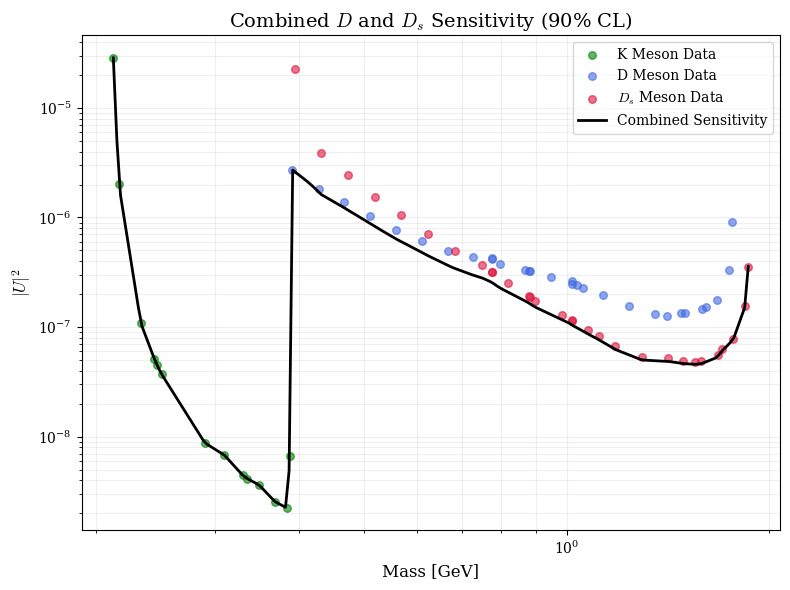

In [587]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Plot the original discrete points from both sources
# Using markers only ('o') to show where the actual data was
ax.scatter(10**sol_k_vmm['Mass'], 10**sol_k_vmm['Ua2'], color='green', label='K Meson Data', alpha=0.6, s=30, zorder=3)
ax.scatter(10**sol_d_vmm['Mass'], 10**sol_d_vmm['Ua2'], color='royalblue', label='D Meson Data', alpha=0.6, s=30, zorder=3)
ax.scatter(10**sol_ds_vmm['Mass'], 10**sol_ds_vmm['Ua2'], color='crimson', label='$D_s$ Meson Data', alpha=0.6, s=30, zorder=3)

# 2. Plot the combined sensitivity line
# This is the "lower envelope" you calculated via log-log interpolation
ax.plot(final_mass_vmm, final_u2_vmm, color='black', linewidth=2, label='Combined Sensitivity', zorder=4)

# 3. Set log-log scales
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Formatting and Labels
ax.set_xlabel('Mass [GeV]', fontsize=12)
ax.set_ylabel(r'$|U|^2$', fontsize=12)
ax.set_title('Combined $D$ and $D_s$ Sensitivity (90% CL)', fontsize=14)

# Add a grid that works well with log scales
ax.grid(True, which="both", ls="-", alpha=0.2)

# Place the legend
ax.legend(frameon=True, loc='best')

# Optional: Tighten layout
plt.tight_layout()
plt.show()

In [588]:
# 1. Transform your data to log space
# Use log10 for easier mental debugging

log_m_K = sol_k_mpi['Mass'].to_numpy()
log_u2_K = sol_k_mpi['Ua2'].to_numpy()

log_m_D = sol_d_mpi['Mass'].to_numpy()
log_u2_D = sol_d_mpi['Ua2'].to_numpy()

log_m_Ds = sol_ds_mpi['Mass'].to_numpy()
log_u2_Ds = sol_ds_mpi['Ua2'].to_numpy()

# 2. Create the common grid in log space
# (e.g., from 0.1 GeV to 2.0 GeV)
log_m_min = min(log_m_K.min(), log_m_D.min(), log_m_Ds.min())
log_m_max = max(log_m_K.max(), log_m_D.max(), log_m_Ds.max())
common_log_mass = np.linspace(log_m_min, log_m_max, 180)

# 3. Interpolate the log values
f_K_log = interp1d(log_m_K, log_u2_K, kind='linear',fill_value=np.inf, bounds_error=False)
f_D_log = interp1d(log_m_D, log_u2_D, kind='linear',fill_value=np.inf, bounds_error=False)
f_Ds_log = interp1d(log_m_Ds, log_u2_Ds, kind='linear', fill_value=np.inf, bounds_error=False)

log_u2_K_interp = f_K_log(common_log_mass)
log_u2_D_interp = f_D_log(common_log_mass)
log_u2_Ds_interp = f_Ds_log(common_log_mass)

# 4. Take the minimum in log space (same as taking min in linear space)
#total_log_u2 = np.minimum(log_u2_D_interp, log_u2_Ds_interp)

# 5. Transform back to linear space for the final result
final_mass_mpi = 10**common_log_mass
u2_K_interp = 10**(f_K_log(common_log_mass))
u2_D_interp = 10**(f_D_log(common_log_mass))
u2_Ds_interp = 10**(f_Ds_log(common_log_mass))

final_u2_mpi = 1.0 / np.sqrt((1.0 / u2_K_interp**2) + (1.0 / u2_D_interp**2) + (1.0 / u2_Ds_interp**2))

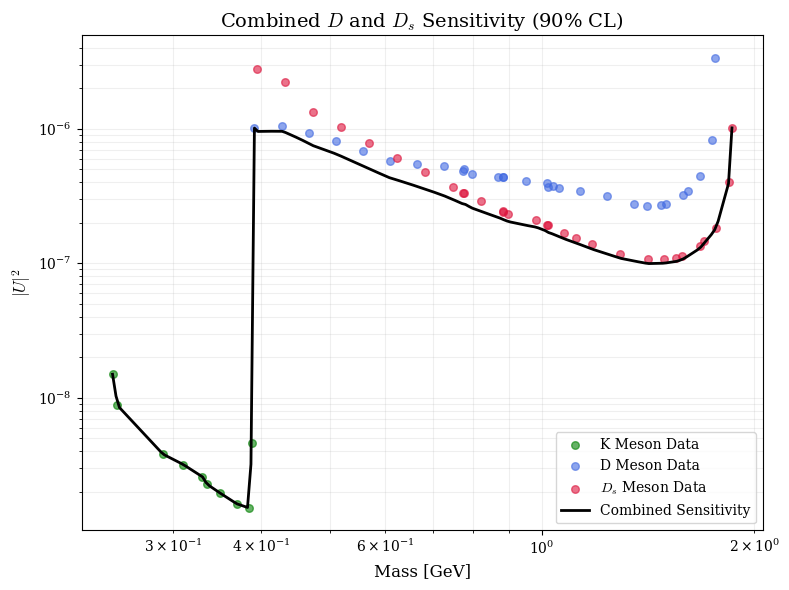

In [589]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Plot the original discrete points from both sources
# Using markers only ('o') to show where the actual data was
ax.scatter(10**sol_k_mpi['Mass'], 10**sol_k_mpi['Ua2'], color='green', label='K Meson Data', alpha=0.6, s=30, zorder=3)
ax.scatter(10**sol_d_mpi['Mass'], 10**sol_d_mpi['Ua2'], color='royalblue', label='D Meson Data', alpha=0.6, s=30, zorder=3)
ax.scatter(10**sol_ds_mpi['Mass'], 10**sol_ds_mpi['Ua2'], color='crimson', label='$D_s$ Meson Data', alpha=0.6, s=30, zorder=3)

# 2. Plot the combined sensitivity line
# This is the "lower envelope" you calculated via log-log interpolation
ax.plot(final_mass_mpi, final_u2_mpi, color='black', linewidth=2, label='Combined Sensitivity', zorder=4)

# 3. Set log-log scales
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Formatting and Labels
ax.set_xlabel('Mass [GeV]', fontsize=12)
ax.set_ylabel(r'$|U|^2$', fontsize=12)
ax.set_title('Combined $D$ and $D_s$ Sensitivity (90% CL)', fontsize=14)

# Add a grid that works well with log scales
ax.grid(True, which="both", ls="-", alpha=0.2)

# Place the legend
ax.legend(frameon=True, loc='best')

# Optional: Tighten layout
plt.tight_layout()
plt.show()

In [590]:
# m_grid_vmm = segments_vmm[:, 0]
# U2_s_only_vmm = segments_vmm[:, 1]

#m_sb_points = np.concatenate((10**sol_k_mpi['Mass'].to_numpy(), 10**sol_d_mpi['Mass'].to_numpy(), 10**sol_ds_mpi['Mass'].to_numpy()))

m_sb_points = final_mass_vmm

true_penalty_log10 = 1.5 - 0.5*m_sb_points + np.random.normal(0, 0.1, len(m_sb_points))

U2_s_only_vmm_at_points = np.interp(m_sb_points, m_grid_vmm, U2_s_only_vmm)
#U2_sb_points_k = U2_s_only_vmm_at_points_k * 10**true_penalty_log10_k
U2_sb_points = final_u2_vmm
# Step 1: Evaluate the S-only template at the S+B mass points
# (We use linear interpolation here assuming the grid is dense enough)
U2_template_at_points = np.interp(m_sb_points, m_grid_vmm, U2_s_only_vmm)
# Step 2: Calculate the log10 ratio (penalty factor) for the discrete points
# R_i = log10(U2_sb_i) - log10(U2_0(m_i))
log_ratio_points = np.log10(U2_sb_points) - np.log10(U2_template_at_points)

# Step 3: Fit a low-order polynomial to the log ratio
# We use a 2nd-order (quadratic) polynomial here
degree = 6
poly_coeffs = np.polyfit(m_sb_points, log_ratio_points, degree)
poly_function = np.poly1d(poly_coeffs)

# Step 4: Evaluate the fitted polynomial over the full continuous mass grid
log_ratio_continuous = poly_function(m_grid_vmm)

# Step 5: Reconstruct the continuous S+B contour
# U2_sb(m) = U2_0(m) * 10^(R(m))
U2_sb_continuous_vmm = U2_s_only_vmm * 10**(log_ratio_continuous)

In [591]:
# m_grid_mpi = segments_mpi[:, 0]
# U2_s_only_mpi = segments_mpi[:, 1]

#m_sb_points = np.concatenate((10**sol_k_mpi['Mass'].to_numpy(), 10**sol_d_mpi['Mass'].to_numpy(), 10**sol_ds_mpi['Mass'].to_numpy()))

m_sb_points = final_mass_mpi

true_penalty_log10 = 1.5 - 0.5*m_sb_points + np.random.normal(0, 0.1, len(m_sb_points))

U2_s_only_mpi_at_points = np.interp(m_sb_points, m_grid_mpi, U2_s_only_mpi)
#U2_sb_points_k = U2_s_only_mpi_at_points_k * 10**true_penalty_log10_k
U2_sb_points = final_u2_mpi
# Step 1: Evaluate the S-only template at the S+B mass points
# (We use linear interpolation here assuming the grid is dense enough)
U2_template_at_points = np.interp(m_sb_points, m_grid_mpi, U2_s_only_mpi)
# Step 2: Calculate the log10 ratio (penalty factor) for the discrete points
# R_i = log10(U2_sb_i) - log10(U2_0(m_i))
log_ratio_points = np.log10(U2_sb_points) - np.log10(U2_template_at_points)

# Step 3: Fit a low-order polynomial to the log ratio
# We use a 2nd-order (quadratic) polynomial here
degree = 6
poly_coeffs = np.polyfit(m_sb_points, log_ratio_points, degree)
poly_function = np.poly1d(poly_coeffs)

# Step 4: Evaluate the fitted polynomial over the full continuous mass grid
log_ratio_continuous = poly_function(m_grid_mpi)

# Step 5: Reconstruct the continuous S+B contour
# U2_sb(m) = U2_0(m) * 10^(R(m))
U2_sb_continuous_mpi = U2_s_only_mpi * 10**(log_ratio_continuous)

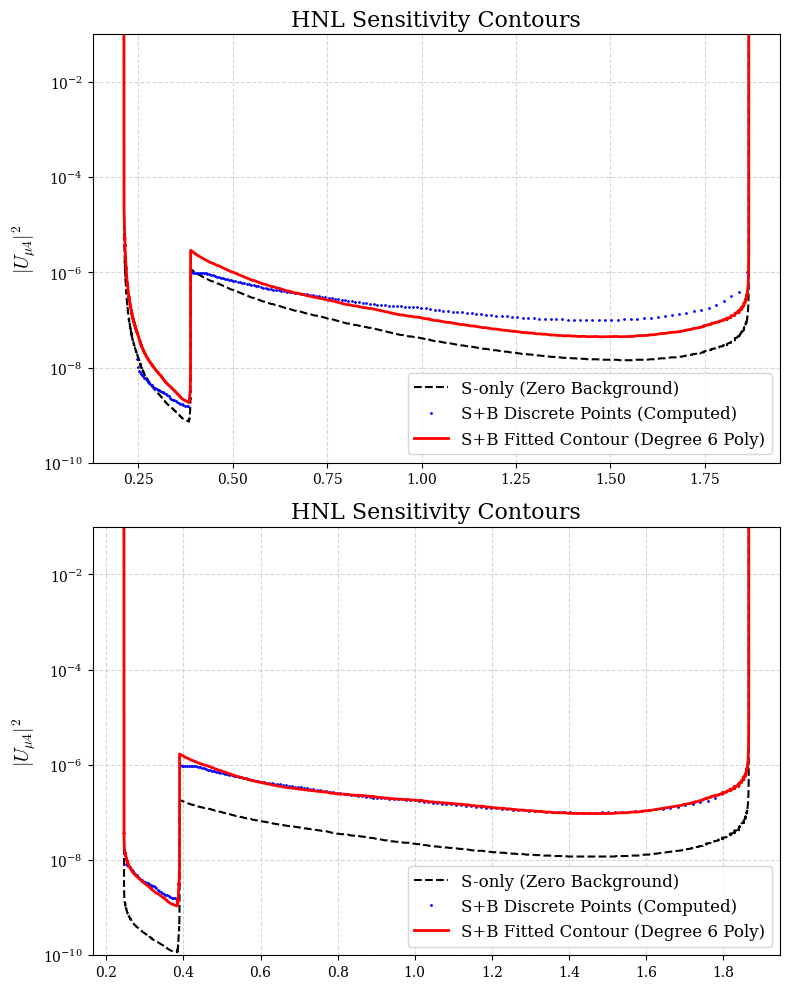

In [592]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [2, 2]}) 
# --- Top Plot: The Physical U^2 vs Mass Plane --- 
ax1.plot(m_grid_vmm, U2_s_only_vmm, 'k--', label='S-only (Zero Background)') 
ax1.plot(m_sb_points, U2_sb_points, 'bo', markersize=1, label='S+B Discrete Points (Computed)')
#ax1.plot(m_sb_points_d, U2_sb_points_d, 'go', markersize=4, label='S+B Discrete Points (Computed)')
#ax1.plot(m_sb_points_k, U2_s_only_at_points_k, 'ro', markersize=4, label='S+B Discrete Points (Computed)') 
ax1.plot(m_grid_vmm, U2_sb_continuous_vmm, 'r-', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
#ax1.plot(m_grid, U2_sb_continuous_d, 'g-', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
# ax1.plot(m_grid, U2_sb_continuous_ds, 'b--', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
ax1.set_yscale('log') 
ax1.set_ylim(1e-10, 1e-1)
ax1.set_ylabel(r'$|U_{\mu 4}|^2$', fontsize=14) 
ax1.set_title('HNL Sensitivity Contours', fontsize=16) 
ax1.legend(fontsize=12) 
ax1.grid(True, which="both", ls="--", alpha=0.5) 
# --- Bottom Plot: The Log-Ratio (Penalty Factor) --- 
# ax2.plot(m_sb_points, log_ratio_points, 'ro', markersize=8, label='Discrete Penalty Points') 
# ax2.plot(m_grid_vmm, log_ratio_continuous, 'r-', label='Polynomial Fit $R(m)$') 
# ax2.set_xlabel(r'$m_N~\text{[GeV]}$', fontsize=14) 
# ax2.set_ylabel(r'$\log_{10}(U^2_{S+B} / U^2_{S})$', fontsize=14) 
# ax2.legend(fontsize=12) 
# ax2.grid(True, ls="--", alpha=0.5) 
ax2.plot(m_grid_mpi, U2_s_only_mpi, 'k--', label='S-only (Zero Background)') 
ax2.plot(m_sb_points, U2_sb_points, 'bo', markersize=1, label='S+B Discrete Points (Computed)')
#ax2.plot(m_sb_points_d, U2_sb_points_d, 'go', markersize=4, label='S+B Discrete Points (Computed)')
#ax2.plot(m_sb_points_k, U2_s_only_at_points_k, 'ro', markersize=4, label='S+B Discrete Points (Computed)') 
ax2.plot(m_grid_mpi, U2_sb_continuous_mpi, 'r-', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
#ax2.plot(m_grid, U2_sb_continuous_d, 'g-', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
# ax2.plot(m_grid, U2_sb_continuous_ds, 'b--', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
ax2.set_yscale('log') 
ax2.set_ylim(1e-10, 1e-1)
ax2.set_ylabel(r'$|U_{\mu 4}|^2$', fontsize=14) 
ax2.set_title('HNL Sensitivity Contours', fontsize=16) 
ax2.legend(fontsize=12) 
ax2.grid(True, which="both", ls="--", alpha=0.5) 
plt.tight_layout() 
plt.show()

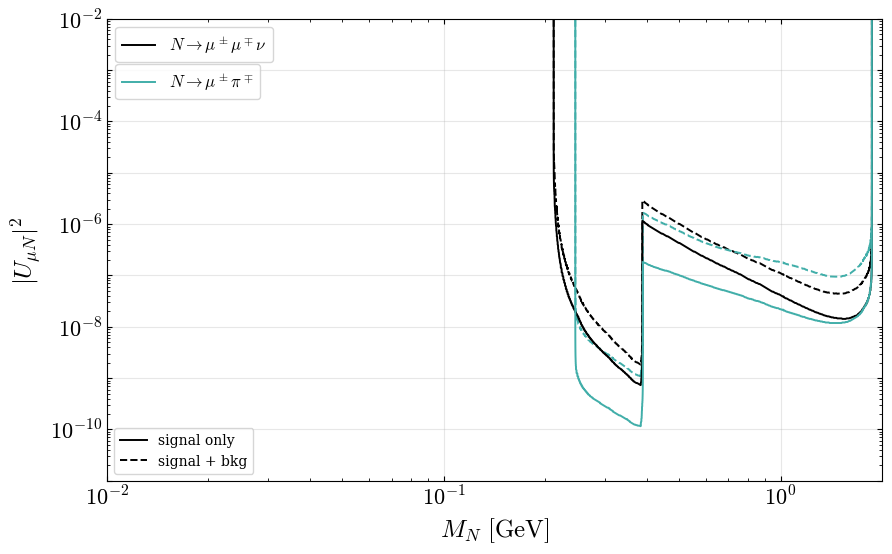

In [598]:

Nev_grid_vmm = grid_vmm_df.pivot_table(values='Nev', index='u2', columns='m', aggfunc='first')
Nev_grid_mpi = grid_mpi_df.pivot_table(values='Nev', index='u2', columns='m', aggfunc='first')

# Create contour plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(m_grid_vmm, U2_sb_continuous_vmm, color='black', linestyle='--', linewidth=1.4, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
ax.plot(m_grid_mpi, U2_sb_continuous_mpi, color='#41AEA9', linestyle='--', linewidth=1.4, label=f'S+B Fitted Contour (Degree {degree} Poly)')

ax.contour(Nev_grid_vmm.columns, Nev_grid_vmm.index, Nev_grid_vmm.values, levels=[2.44], colors='black', linewidths=1.4)
ax.contour(Nev_grid_mpi.columns, Nev_grid_mpi.index, Nev_grid_mpi.values, levels=[2.44], colors='#41AEA9', linewidths=1.4)
# Extract the paths
# allsegs is a nested list: [level_index][segment_index]
# Since we only have one level, we use index 0.
#segments_vmm = contour.allsegs[0]
# ax.scatter(10**sol_k_vmm['Mass'], 10**sol_k_vmm['Ua2'], color='#4A2DBD', label='Optimal cuts: K', zorder=5, alpha=0.7, marker='.')
# ax.scatter(10**sol_d_vmm['Mass'], 10**sol_d_vmm['Ua2'], color="#4A2DBD", label='Optimal cuts: D', zorder=5, alpha=0.7, marker='.')
# ax.scatter(10**sol_ds_vmm['Mass'], 10**sol_ds_vmm['Ua2'], color="#4A2DBD", label='Optimal cuts: Ds', zorder=5, alpha=0.7, marker='.')

# ax.scatter(10**sol_k_mpi['Mass'], 10**sol_k_mpi['Ua2'], color='#BD2D5D', label='Optimal cuts: K', zorder=5, alpha=0.7, marker='.')
# ax.scatter(10**sol_d_mpi['Mass'], 10**sol_d_mpi['Ua2'], color="#BD2D5D", label='Optimal cuts: D', zorder=5, alpha=0.7, marker='.')
# ax.scatter(10**sol_ds_mpi['Mass'], 10**sol_ds_mpi['Ua2'], color="#BD2D5D", label='Optimal cuts: Ds', zorder=5, alpha=0.7, marker='.')

#ax.plot(m_grid_vmm, U2_sb_continuous_vmm, color='black', linestyle='--', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)') 
#ax.plot(m_grid_mpi, U2_sb_continuous_mpi, color='#41AEA9', linestyle='--', linewidth=2, label=f'S+B Fitted Contour (Degree {degree} Poly)')

#ax.clabel(contour, inline=True, fontsize=10)
# 1. Create the first legend (Contour/Line)
line_handle = [Line2D([0], [0], color='black', lw=1.4)]
line_label = [r'$N\to \mu^\pm\mu^\mp\nu$']
leg1 = ax.legend(line_handle, line_label, loc='upper left', fontsize=12)

# 2. IMPORTANT: Add the first legend manually so it isn't overwritten
ax.add_artist(leg1)

# 3. Create the second legend (Scatter)
# Assuming 'sc' is your scatter plot object: sc = ax.scatter(...)
# If you haven't defined 'sc', you can use a Proxy Artist like this:
scatter_handle = [Line2D([0], [0], marker='.', color='w', 
                         markerfacecolor='#41AEA9', markersize=10)] 
line_handle2 = [Line2D([0], [0], color='#41AEA9', lw=1.4)]
line_label2 = [r'$N\to \mu^\pm\pi^\mp$']
#scatter_label = [r'$N\to \mu^\pm\mu^\mp\nu~\text{- bkg}$']

leg2 = ax.legend(line_handle2, line_label2, 
          loc='upper left', 
          bbox_to_anchor=(0, 0.92), # Adjust 0.92 based on your plot's aspect ratio
          fontsize=12,
          frameon=True)

ax.add_artist(leg2)

# 3. Create handles for the custom legend
# color='black' or 'grey' is usually best for "style" indicators
custom_lines = [
    Line2D([0], [0], color='black', lw=1.4, linestyle='-'),
    Line2D([0], [0], color='black', lw=1.4, linestyle='--')
]

# 4. Add the second legend
ax.legend(custom_lines, ['signal only', 'signal + bkg'], loc='lower left')

# Customize ticks
ax = plt.gca()
# asp_fact=(np.log10(4)-np.log10(1e-3))/(np.log10(ymax)-np.log10(ymin))
# ax.set_aspect(asp_fact)
plt.xscale('log')
plt.yscale('log')

# The logic: hide labels if the log10 of the value is odd
def log_y_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    if exponent % 2 == 0:
        return f'$10^{{{exponent}}}$'
    else:
        return '' # Keep the tick, hide the label
    
def log_x_formatter(x, pos):
    exponent = int(np.round(np.log10(x)))
    # if exponent % 2 == 0:
    #     return f'$10^{{{exponent}}}$'
    # else:
    #     return '' # Keep the tick, hide the label
    return f'$10^{{{exponent}}}$'

#ax.yaxis.set_major_formatter(plt.FuncFormatter(log_formatter))

# Show ticks on all four sides
ax.tick_params(top=True, right=True, which='both', direction='in')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_x_formatter))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
#ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_y_formatter))
ax.tick_params(axis='both', labelsize=16)

plt.xlabel(r'$M_N~[\text{GeV}]$', fontsize=18)
plt.ylabel(r'$|U_{\mu N}|^2$', fontsize=18)
plt.xlim(1e-2, 2)
plt.ylim(1e-11, 1e-2)
#plt.title(r'Contour at $N_{ev}$ = 2.61')
plt.grid(True, alpha=0.3)
plt.show()

In [481]:
def lamb(a,b,c):
    return a**2 + b**2 + c**2 - 2*a*b -2*b*c -2*a*c

def GammaDsNl(mN,U2,ml):
    GF = 1.166370e-5
    fDs = 0.249
    Vcs = 0.97414
    mDs = 1.9683
    y4 = mN/mDs
    yl = ml/mDs
    result = GF**2*mDs**3/(8*np.pi)*fDs**2*U2*Vcs**2*np.sqrt(lamb(1,y4**2,yl**2))*(y4**2+yl**2-(y4**2-yl**2)**2)
    return result

GammaDsNl(1,1e-8,0.105658)

3.505408009032063e-21

In [467]:
GammaDsNl(0.1,1e-7,0.105658)

1.3193582755837512e-21

In [478]:
GammaDsNl(0.01,1e-7,0.105658)/GammaDs 

5.408590918050809e-10

In [484]:
6.5821e-16/501.2e-15/1e9

1.313268156424581e-12

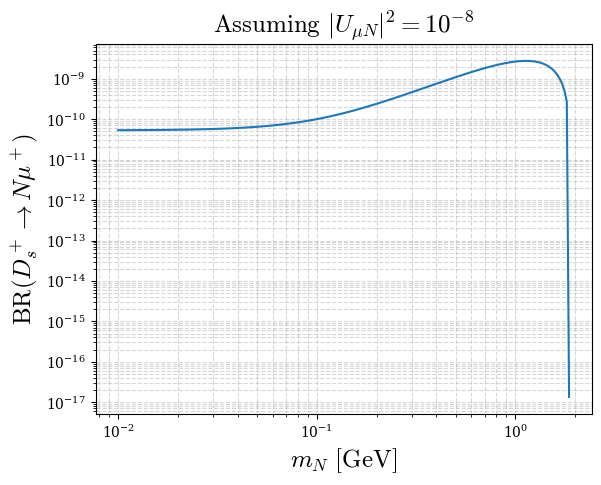

In [485]:
GammaDs = 1.298e-12
GammaDs = 6.5821e-16/501.2e-15/1e9

masa = np.linspace(np.log10(0.01), np.log10(1.9683-0.105658), 200)
plt.plot(10**masa, GammaDsNl(10**masa,1e-8,0.105658)/GammaDs)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$m_N~\text{[GeV]}$', fontsize=18)
plt.ylabel(r'$\text{BR}(D_s^+ \to N \mu^+)$', fontsize=18)
plt.title(r'$\text{Assuming }\vert U_{\mu N}\vert^2 = 10^{-8}$', fontsize=18)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [451]:
3.5e-23/1.298e-12

2.696456086286595e-11

In [490]:
# SHiP expects about 6e20 PoT in 15 years. 
# K0L production is about 0.07 per PoT, and the BR of K0L to e mu is about 3e-15 for U2=1e-3.
(1e-6/1e-3)**2*3e-15*0.07*6e20 # in 15 years 

0.126

In [ ]:
df_signal_plot[(df_signal_plot['pS']<0.187) & (df_signal_plot['DthetaS']<0.9291086720028764)].weight.sum()/df_signal_plot['weight'].sum()*100

99.97945938454166

In [ ]:
df_signal_plot[(df_signal_plot['pS']<0.187) & (df_signal_plot['DthetaS']>0)].weight.sum()/df_signal_plot['weight'].sum()*100

99.97945938454166

In [ ]:
df_plot_bkg[(df_plot_bkg['pS']<0.187)]

,event,pdg,px,py,pz,E,pT,pS,Dtheta,DthetaS


In [ ]:
len(df_plot_bkg[(df_plot_bkg['pS']<0.17489079324394569) & (df_plot_bkg['DthetaS']<0.8885498427822938)])/len(df_plot_bkg)*100

0.0

In [ ]:
find_optimal_cuts(df_signal_plot['212'], df_plot_bkg, pS_direction='less', DthetaS_direction='less', 
                      sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=50)

Starting grid search for optimal cuts...


({'pS': 0.3865754043543037, 'DthetaS': 0.1110221359367065},
 0.11229135680841261,
 100.0,
 0.0,
 0.0,
 1.3910687158642522e-05)

In [ ]:
df_signal_plot.keys()

dict_keys(['212', '290', '349', '384'])

In [ ]:
find_optimal_cuts(df_signal_plot['290'], df_plot_bkg, pS_direction='less', DthetaS_direction='less', 
                      sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=50)

Starting grid search for optimal cuts...


({'pS': 0.21345548587610305, 'DthetaS': 0.9993953837251015},
 689.0362027446004,
 99.9949313277425,
 1.4084507042253522,
 51.4024,
 5.6938435978313295e-09)

In [ ]:
find_optimal_cuts(df_signal_plot['349'], df_plot_bkg, pS_direction='less', DthetaS_direction='less', 
                      sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=50)

Starting grid search for optimal cuts...


({'pS': 0.35102776542658587, 'DthetaS': 1.6096086136379553},
 2169.3635874012894,
 100.0,
 2.8169014084507045,
 102.8048,
 2.1507577168330785e-09)

In [ ]:
find_optimal_cuts(df_signal_plot['384'], df_plot_bkg, pS_direction='less', DthetaS_direction='less', 
                      sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=50)

Starting grid search for optimal cuts...


({'pS': 0.3548775183346063, 'DthetaS': 2.274731631326447},
 3518.2137699369164,
 100.0,
 4.225352112676056,
 154.2072,
 1.4676634028201626e-09)

In [ ]:
find_optimal_cuts(df_signal_plot, df_plot_bkg, pS_direction='less', DthetaS_direction='less', 
                      sig_weight_col='weight', bkg_norm_factor=norm_bkg, grid_size=50)

Starting grid search for optimal cuts...


({'pS': 0.4029265325348115, 'DthetaS': 0.8885498427822938},
 488.10032632703684,
 100.0,
 100.0)

In [ ]:
def find_optimal_cuts(df_sig, df_bkg, pt_direction='greater', angle_direction='less', grid_size=50):
    """
    Finds the optimal cuts on pT and angle to maximize S / sqrt(S + B).
    """
    print("Starting grid search for optimal cuts...")
    
    # Determine the search ranges based on the data (using quantiles to ignore extreme outliers)
    pt_min = min(df_sig['pT'].quantile(0.01), df_bkg['pT'].quantile(0.01))
    pt_max = max(df_sig['pT'].quantile(0.99), df_bkg['pT'].quantile(0.99))
    
    angle_min = min(df_sig['angle'].quantile(0.01), df_bkg['angle'].quantile(0.01))
    angle_max = max(df_sig['angle'].quantile(0.99), df_bkg['angle'].quantile(0.99))
    
    # Create the grid
    pt_cuts = np.linspace(pt_min, pt_max, grid_size)
    angle_cuts = np.linspace(angle_min, angle_max, grid_size)
    
    best_significance = 0
    best_cuts = {'pT': None, 'angle': None}
    
    # Extract underlying numpy arrays for much faster evaluation than pandas series
    sig_pt, sig_angle = df_sig['pT'].values, df_sig['angle'].values
    bkg_pt, bkg_angle = df_bkg['pT'].values, df_bkg['angle'].values
    
    # Iterate through the grid
    for pT_cut in pt_cuts:
        for angle_cut in angle_cuts:
            
            # 1. Apply pT cut
            if pt_direction == 'greater':
                sig_pass_pt = sig_pt > pT_cut
                bkg_pass_pt = bkg_pt > pT_cut
            else:
                sig_pass_pt = sig_pt < pT_cut
                bkg_pass_pt = bkg_pt < pT_cut
                
            # 2. Apply angle cut
            if angle_direction == 'greater':
                sig_pass_angle = sig_angle > angle_cut
                bkg_pass_angle = bkg_angle > angle_cut
            else:
                sig_pass_angle = sig_angle < angle_cut
                bkg_pass_angle = bkg_angle < angle_cut
            
            # Combine cuts (Logical AND)
            sig_pass = sig_pass_pt & sig_pass_angle
            bkg_pass = bkg_pass_pt & bkg_pass_angle
            
            # Calculate S and B (assuming weight of 1 per event. Sum weights if using weighted data)
            S = np.sum(sig_pass)
            B = np.sum(bkg_pass)
            
            # Calculate Significance (Avoid division by zero)
            if S + B > 0:
                significance = S / np.sqrt(S + B)
            else:
                significance = 0
                
            # Update best cuts if current significance is higher
            if significance > best_significance:
                best_significance = significance
                best_cuts = {'pT': pT_cut, 'angle': angle_cut}
                
    return best_cuts, best_significance

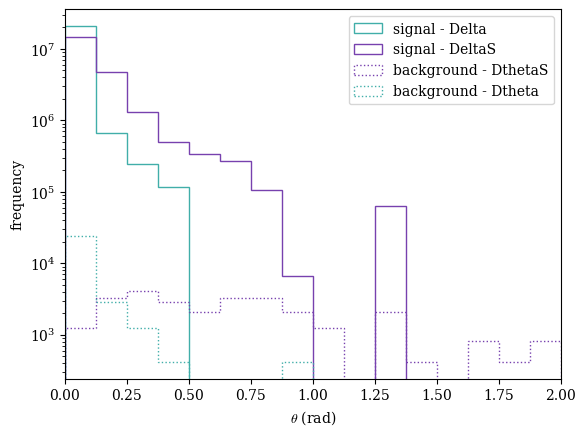

In [ ]:
rango = 2
bines = 16

plt.hist(df_plot['Dtheta'],label= 'signal - Delta', bins=bines, weights=bines/rango*df_plot['weight'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
plt.hist(df_plot['DthetaS'],label= 'signal - DeltaS', bins=bines, weights=bines/rango*df_plot['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')
plt.hist(df_plot_bkg['DthetaS'],label= 'background - DthetaS', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['DthetaS']/df_plot_bkg['DthetaS'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step', linestyle=':')
plt.hist(df_plot_bkg['Dtheta'],label= 'background - Dtheta', bins=bines, weights=norm_bkg*bines/rango*df_plot_bkg['Dtheta']/df_plot_bkg['Dtheta'], range=[0,rango], alpha=1, color="#41AEA9", histtype=u'step', linestyle=':')

plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$\theta$ (rad)')
plt.xlim((0,rango))
plt.ylabel(r'frequency')
plt.yscale('log')
#plt.ylim((1e-16,1e-9))
plt.show()

In [ ]:
df_bkg = pd.DataFrame()

for i in range(0,404):
    if i<9:
        file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_00{i}.txt'
    else:
        if i<99:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_0{i}.txt'
        else:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_{i}.txt'
    if os.path.isfile(file):
        df = pd.read_csv(file, sep='\t')
        df_bkg = pd.concat([df_bkg, df], ignore_index=True)
df_bkg

,event,pdg,px,py,pz,E
0,0,13,-0.495800,-0.336426,61.414156,61.417170
1,0,-13,0.896474,0.399160,0.942188,1.364506
2,0,13,1.736432,0.811889,45.482222,45.522720
3,0,-13,-0.575063,0.436374,1.765281,1.910105
4,0,13,0.244237,-0.697380,3.003336,3.094702
...,...,...,...,...,...,...
137,1,-13,-0.577610,-0.117531,0.549815,0.812962
138,0,13,0.282671,0.458020,4.203148,4.238786
139,0,-13,0.039170,-0.831925,0.765578,1.136181
140,0,13,0.143725,-0.059405,22.560357,22.561141


In [ ]:
df_bkg = pd.DataFrame()

for i in range(0,404):
    if i<9:
        file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_00{i}.txt'
    else:
        if i<99:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_0{i}.txt'
        else:
            file = f'/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/bkg/to_mumu/neutrino_mumu_NDLAr_{i}.txt'
    if os.path.isfile(file):
        df = pd.read_csv(file, sep='\t')
        df_bkg = pd.concat([df_bkg, df], ignore_index=True)
df_bkg

df_plot_bkg = pd.DataFrame()
for i in range(0,len(df_bkg),2):
    transverse = pT(df_bkg['px'].loc[i+1],df_bkg['px'].loc[i],df_bkg['py'].loc[i+1],df_bkg['py'].loc[i])
    transverseS = pS(df_bkg['px'].loc[i+1],df_bkg['px'].loc[i],df_bkg['py'].loc[i+1],df_bkg['py'].loc[i])
    angle = theta(df_bkg['px'].loc[i+1]+df_bkg['px'].loc[i],df_bkg['py'].loc[i+1]+df_bkg['py'].loc[i],df_bkg['pz'].loc[i+1]+df_bkg['pz'].loc[i])
    angleS = thetaS(df_bkg['px'].loc[i+1],df_bkg['py'].loc[i+1],df_bkg['pz'].loc[i+1],df_bkg['px'].loc[i],df_bkg['py'].loc[i],df_bkg['pz'].loc[i])
    #new_colupx = pd.DataFrame([[transverse,transverseS,angle,angleS]],colupxs=['pT','pS','Dtheta','DthetaS'])
    row = df_bkg.loc[i].copy()
    row['pT'] = transverse
    row['pS'] = transverseS
    row['Dtheta'] = angle
    row['DthetaS'] = angleS
    # frames = [df.loc[i], new_colupx]
    df_plot_bkg = pd.concat([df_plot_bkg,row.to_frame().T],ignore_index=True)

<Axes: >

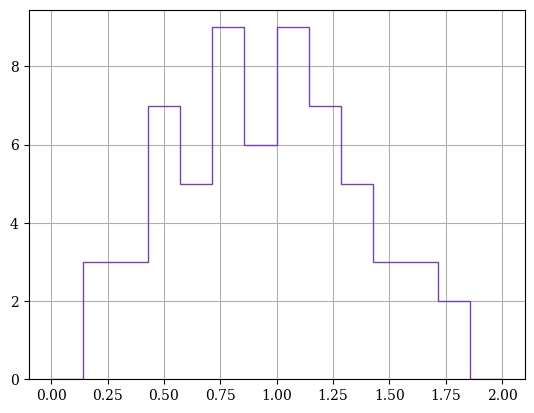

In [ ]:
rango = 2
bines = 14

df_plot_bkg['pS'].hist(bins=bines, range=[0,rango], histtype=u'step', color="#7741AE")

In [ ]:
file = '/Users/ific/protoDUNE/DUNE_ND_nu_flux/lightnu_NM_numu.data'
flujo_numu = pd.read_csv(file, sep='\t', header=None, names=['energy', 'flux'])

file = '/Users/ific/Desktop/saltitos_flux_test/lightnu_flux_files/paper_flux_for_GLoBES/final_bien/DUNE_PRISM_HNLux_neutrino_0mrad_final.txt'
flujo_all_0mrad = pd.read_csv(file, sep=' ', header=None, names=['energy', 'nue_flux', 'numu_flux', 'nutau_flux', 'nuebar_flux', 'numubar_flux', 'nutaubar_flux'])
file = '/Users/ific/Desktop/saltitos_flux_test/lightnu_flux_files/paper_flux_for_GLoBES/final_mal/DUNE_PRISM_HNLux_neutrino_0mrad_final.txt'
flujo_all_0mrad_mal = pd.read_csv(file, sep=' ', header=None, names=['energy', 'nue_flux', 'numu_flux', 'nutau_flux', 'nuebar_flux', 'numubar_flux', 'nutaubar_flux'])

file = '/Users/ific/Desktop/saltitos_flux_test/histos_g4lbne_v3r5p4_QGSP_BERT_OptimizedEngineeredNov2017_neutrino_LBNEND_globes_flux.txt'
df_LBNEND = pd.read_csv(file, index_col=False, sep=' ', names = ['E', 'nue', 'numu', 'nutau', 'nuebar', 'numubar', 'nutaubar'])

In [ ]:
flujo_all_0mrad['energy'].iloc[1]-flujo_all_0mrad['energy'].iloc[0]

0.25

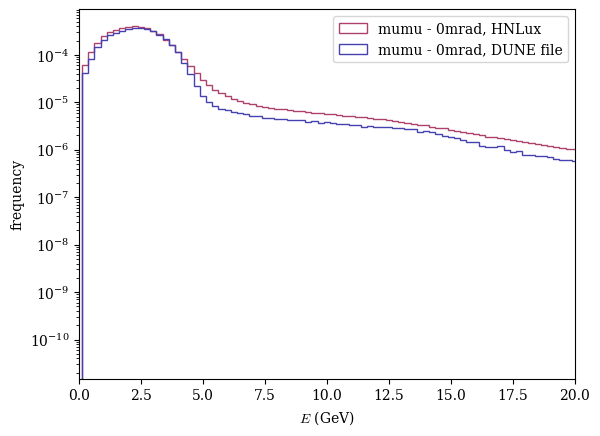

In [ ]:
rango = flujo_all_0mrad_mal['energy'].max()
bines = 60

#plt.hist(flujo_numu['energy'],label= 'mumu - NM', bins=flujo_all_0mrad['energy'], weights=flujo_numu['flux']*100*100, range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
plt.hist(flujo_all_0mrad['energy'],label= 'mumu - 0mrad, HNLux', bins=flujo_all_0mrad['energy'], weights=flujo_all_0mrad['numu_flux'], range=[0,rango], alpha=1, color="#AE416B", histtype=u'step')
#plt.hist(flujo_all_0mrad_mal['energy'],label= 'mumu - 0mrad, HNLux mal', bins=flujo_all_0mrad_mal['energy'], weights=flujo_all_0mrad_mal['numu_flux'], range=[0,rango], alpha=1, color="#4541AE", histtype=u'step', linestyle=':')
#plt.scatter(flujo_all_0mrad['energy'], 1/0.25*flujo_all_0mrad['numu_flux']/100/100, color='red')
plt.hist(df_LBNEND['E'],label= 'mumu - 0mrad, DUNE file', bins=df_LBNEND['E'], weights=df_LBNEND['numu'], range=[0,rango], alpha=1, color="#4541AE", histtype=u'step')

#plt.hist(df_plot['DthetaS'],label= 'signal - DeltaS', bins=bines, weights=bines/rango*df_plot['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')

plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$E$ (GeV)')
plt.xlim((0,20))
plt.ylabel(r'frequency')
plt.yscale('log')
#plt.ylim((1e-16,1e-9))
plt.show()

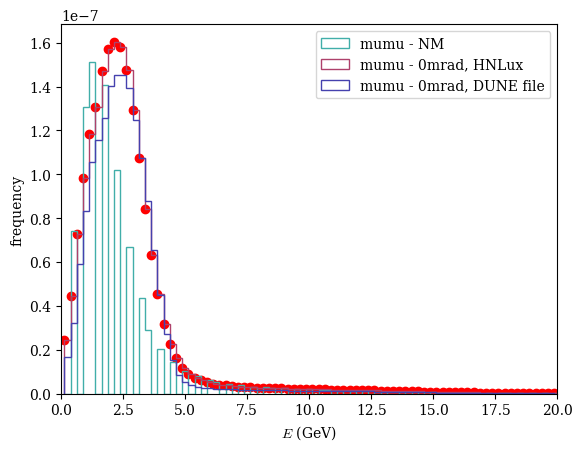

In [ ]:
rango = 60
bines = 60

plt.hist(flujo_numu['energy'],label= 'mumu - NM', bins=flujo_all_0mrad['energy'], weights=1/0.25*flujo_numu['flux'], range=[0,rango], alpha=1, color='#41AEA9', histtype=u'step')
plt.hist(flujo_all_0mrad['energy'],label= 'mumu - 0mrad, HNLux', bins=flujo_all_0mrad['energy'], weights=1/0.25*flujo_all_0mrad['numu_flux']/100/100, range=[0,rango], alpha=1, color="#AE416B", histtype=u'step')
plt.scatter(flujo_all_0mrad['energy'], 1/0.25*flujo_all_0mrad['numu_flux']/100/100, color='red')
plt.hist(df_LBNEND['E'],label= 'mumu - 0mrad, DUNE file', bins=flujo_all_0mrad['energy'], weights=1/0.25*df_LBNEND['numu']/100/100, range=[0,rango], alpha=1, color="#4541AE", histtype=u'step')

#plt.hist(df_plot['DthetaS'],label= 'signal - DeltaS', bins=bines, weights=bines/rango*df_plot['weight'], range=[0,rango], alpha=1, color="#7741AE", histtype=u'step')

plt.legend(ncol=1, loc='upper right')
plt.xlabel(r'$E$ (GeV)')
plt.xlim((0,20))
plt.ylabel(r'frequency')
#plt.yscale('log')
#plt.ylim((1e-16,1e-9))
plt.show()

In [ ]:
nombres = ['M_weight', 'N_weight', 'MN', 'USQUARED', 'L_lab_N', 'x_0', 'y_0', 'z_0', 'thetaN', 'phiN', 'x_f', 'y_f', 'z_f', 'M_width_CM', 'BR_M', 'N_total_width_CM', 'BR_N', 'time_N', 'time_nu', 'PoT_f']

In [ ]:
alpha = 0.101
beta = 0

z_DUNE = 574
d_hall_detector = 2.43
h = 2
l = 4
w = 6
dOA_X = 0
dOA_Y = 0



z_DUNE_LArTPC = z_DUNE + d_hall_detector/np.cos(alpha)                     # total distance from the target to detector [in m]
z_DUNE_LArTPC2 = z_DUNE_LArTPC + l/np.cos(alpha)/2                         # total distance from the target to the center of detector [in m]
XMIN = dOA_X-w/2                                                           # m
XMAX = dOA_X+w/2                                                           # m
YMIN = dOA_Y-h/2                                                           # m
YMAX = dOA_Y+h/2                                                           # m
ZMIN = z_DUNE_LArTPC2-l/2                                                     # m
ZMAX = z_DUNE_LArTPC2+l/2                                                     # m

# def xhall(x, z):
#     return np.cos(beta) * x - np.sin(beta) * (z - z_DUNE_LArTPC2)
# def yhall(x, y, z):
#     return np.cos(alpha) * y - np.sin(alpha) * ( (z - z_DUNE_LArTPC2) * np.cos(beta) + np.sin(beta) * x)
# def zhall(x, y, z):
#     return np.sin(alpha) * y + np.cos(alpha) * ( (z - z_DUNE_LArTPC2) * np.cos(beta) + np.sin(beta) * x)

In [ ]:
XMIN, XMAX, YMIN, YMAX, ZMIN, ZMAX

(-3.0, 3.0, -1.0, 1.0, 576.4526916541422, 580.4526916541422)

In [ ]:
XMAX - XMIN - w, YMAX - YMIN - h, ZMAX - ZMIN - l

(0.0, 0.0, 0.0)

In [ ]:
def compute_weight(Lambda, D, d):
    weight = exp( -D/Lambda )*(1-exp( -d/Lambda ))
    return weight

def rotation_y(alpha):
    """Rotation matrix around Y axis by angle alpha (radians)."""
    return np.array([
        [1, 0, 0],
        [0, cos(alpha), sin(alpha)],
        [0,-sin(alpha), cos(alpha)]
    ])

def HNL_direction(th, ph):
    """
    Particle direction vector u(th, ph) with physics convention:
    th: polar angle from +Z (radians)
    ph: azimuth around Z (radians)
    Returns a unit vector.
    """
    return np.array([
        sin(th) * sin(ph),
        sin(th) * cos(ph),
        cos(th)
    ])

def detector_intersection_and_distance(p0, u, box_min, box_max, d, theta):
    """
    Intersect a ray p(t)=p0+t*u with a rotated-translated axis-aligned box.
    Returns entry/exit points in XYZ and traveled distances from p0.

    Parameters
    ----------
    p0 : (3,) array_like
        Ray origin in XYZ.
    u : (3,) array_like
        Ray direction in XYZ (ideally unit-length).
    box_min, box_max : (3,) array_like
        Min/max corners of the box in local X'Y'Z'.
    d : (3,) array_like
        Translation of the box in XYZ.
    theta : float
        Rotation angle (radians) about global Y axis.

    Returns
    -------
    (p_enter, p_exit, dist_enter, dist_exit) or None
        Entry/exit points in XYZ and distances from p0 along the ray.
        If no intersection, returns None.
    """
    R = rotation_y(theta)
    R_T = R.T

    # Transform ray into local coordinates
    p0_prime = R_T @ (p0 - d)
    u_prime = R_T @ u

    # If u is not unit, we'll scale distances appropriately
    u_norm = np.linalg.norm(u)
    if u_norm == 0:
        return None

    tmin, tmax = -np.inf, np.inf

    for i in range(3):
        ui = u_prime[i]
        pi = p0_prime[i]
        if abs(ui) < 1e-12:
            # Parallel to slab: must be within bounds on this axis
            if pi < box_min[i] or pi > box_max[i]:
                return None
        else:
            t1 = (box_min[i] - pi) / ui
            t2 = (box_max[i] - pi) / ui
            t_near, t_far = min(t1, t2), max(t1, t2)
            tmin = max(tmin, t_near)
            tmax = min(tmax, t_far)
            if tmin > tmax:
                return None

    if tmax < 0:
        return None  # Entire box behind the ray origin

    # Entry is the first non-negative intersection along the ray
    t_enter = max(tmin, 0.0)
    t_exit = tmax

    p_enter_prime = p0_prime + t_enter * u_prime
    p_exit_prime  = p0_prime + t_exit  * u_prime

    # Back to global XYZ
    p_enter = d + R @ p_enter_prime
    p_exit  = d + R @ p_exit_prime

    # Distances from origin along the ray:
    # If u is unit, distance = t. Otherwise, scale by ||u||.
    dist_enter = t_enter * u_norm
    dist_exit  = t_exit  * u_norm

    return p_enter, p_exit, p_enter_prime, p_exit_prime, dist_enter, dist_exit

def random_decay_point_and_distance(p_enter, p_exit):
    """
    Choose a random point between p_enter and p_exit.
    Returns the point and the distance from p_enter.
    """
    # Random fraction between 0 and 1
    t = np.random.rand()
    # Point along the segment
    p_rand = p_enter + t * (p_exit - p_enter)
    # Distance from p_enter
    #dist = np.linalg.norm(p_rand - p_enter)
    dist = np.linalg.norm(p_exit - p_enter)
    return p_rand, dist

InvGeVtoMeters = 0.197e-15
def LengthLab_N4(GammaCM, USquared, EN, MN):
    # we divide gammaCM by U^2 since the total width has been computed with madgraph for U = 10^-3
    GammaCM_rescaled = GammaCM * USquared / ((1e-3)**2)     # in GeV
    tauCM = 1 / GammaCM_rescaled                            # in GeV^-1
    LengthCM = InvGeVtoMeters * tauCM                       # in m
    pN = np.sqrt(EN**2 - MN**2)                                # in GeV 
    LengthLab = pN / MN * LengthCM                          # in m
    return LengthLab

In [ ]:
box_min = np.array([XMIN, YMIN, -l/2])
box_max = np.array([XMAX, YMAX, l/2])
# Box transform
dispB = np.array([0, 0, z_DUNE_LArTPC2])

In [ ]:
# mixing = 'Um42'
# channel = 'to_numumu'
# mode = 'neutrino'
# parent = 'NM_kaon+'

if mode == 'neutrino':
    N = 'n'
else:
    if mode == 'antineutrino':
        N = 'n~'

#mass = 310
for mass in um42_grid:

    file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/%s/%s/events-%sdecay-%sMeV-1e-06-from%s.dat'%(mixing, channel, N, mass, parent)
    zipped_file = file + '.gz'
    if os.path.exists(zipped_file):
        run(['gunzip', zipped_file])
    #else:
        #print(f"File {zipped_file} does not exist.")
    if os.path.exists(file):
        df = pd.read_csv(file, delim_whitespace=True, names=nombres, skiprows=2)
        df_final = pd.DataFrame(columns=nombres+['N_weight_final','E', 'dist_to_enter', 'dist_in_det', 'x_final', 'y_final', 'z_final'])

        for i in range(40,len(df),5):
            evento = i

            x_0_test = df['x_0'].iloc[evento]
            y_0_test = df['y_0'].iloc[evento]
            z_0_test = df['z_0'].iloc[evento]
            thetaN_test = df['thetaN'].iloc[evento]
            phiN_test = df['phiN'].iloc[evento]  
            N_total_width_CM_test = df['N_total_width_CM'].iloc[evento]
            EN_test = df['L_lab_N'].iloc[evento+1] + df['L_lab_N'].iloc[evento+2] + df['L_lab_N'].iloc[evento+3]
            MN_test = df['MN'].iloc[evento]

            p0 = np.array([x_0_test, y_0_test, z_0_test])
                
            hnl_direct = HNL_direction(thetaN_test, phiN_test)
            result = detector_intersection_and_distance(p0, hnl_direct, box_min, box_max, dispB, alpha)
            if result is not None:
                p_enter, p_exit, p_enter_prime, p_exit_prime, dist_to_enter, dist_exit = result
                pf, dist_in_det = random_decay_point_and_distance(p_enter, p_exit)
                L_lab_N = LengthLab_N4(N_total_width_CM_test, 1e-6, EN_test, MN_test)
                N_weight = compute_weight(L_lab_N, dist_to_enter, dist_in_det)
                print(f"Event {evento}:")
                #print(f"  Entry point (global XYZ): {p_enter}")
                #print(f"  Exit point (global XYZ): {p_exit}")
                #print(f"  Entry point (local X'Y'Z'): {p_enter_prime}")
                #print(f"  Exit point (local X'Y'Z'): {p_exit_prime}")
                #print(f"  Distance from origin to entry: {dist_to_enter:.2f} m")
                #print(f"  Distance from origin to exit: {dist_exit:.2f} m")
                #print(f"  Random decay point in detector: {pf}")
                #print(f"  Distance traveled in detector: {dist_in_det:.2f} m")
                #print(f"  Computed weight for this event: {N_weight:.3e}")
                # Append to df_final
                row = df.iloc[evento].copy()
                row['N_weight_final'] = N_weight
                row['E'] = EN_test
                row['dist_to_enter'] = dist_to_enter
                row['dist_in_det'] = dist_in_det
                row['x_final'] = pf[0]
                row['y_final'] = pf[1]
                row['z_final'] = pf[2]
                df_final = pd.concat([df_final, row.to_frame().T], ignore_index=True)
                df_final = pd.concat([df_final, df.iloc[evento+1:evento+4]], ignore_index=True)  # Add the next 3 rows for the same event
            #else:
                #print(f"Event {evento}: No intersection with the detector.")
        out_file = '/Users/ific/Desktop/HNL_DUNE_ND_signal_bkg/signal/%s/%s/filter/events-%sdecay-%sMeV-1e-06-from%s.dat'%(mixing, channel, N, mass, parent)
        df_final.to_csv(out_file, index=False, sep='\t')